In [6]:
# %pip install pyarrow

In [7]:
import pandas as pd
import numpy as np


In [8]:
### LOAD IN DATA
data = pd.read_parquet('../data/interim/cases/NHSN-HRD_archive/preliminary/NHSN-HRD_reference-date-2026-05-02_gathered-2026-04-29-18-35-44.parquet.gzip')
pop = pd.read_csv('../data/interim/demography/demography.csv')

# SP26 work was done with older data,'NHSN-HRD_reference-date-2026-03-14_gathered-2026-03-11-18-20-58.parquet.gzip'

In [9]:
### CLEAN

# we don't need USA total (FIPS code 0) for calculating DTW between states
data = data[data["fips_state"] != 0] 
pop = pop[pop["fips_state"] != 0]

In [10]:
data

,season,year,MMWR,date,fips_state,name_state,influenza admissions,covid-19 admissions,rsv admissions
1,2022-2023,2022,37,2022-09-10,1,AL,12.0,589.0,NaN
2,2022-2023,2022,37,2022-09-10,2,AK,5.0,69.0,NaN
3,2022-2023,2022,37,2022-09-10,4,AZ,4.0,388.0,NaN
4,2022-2023,2022,37,2022-09-10,5,AR,6.0,303.0,NaN
5,2022-2023,2022,37,2022-09-10,6,CA,36.0,3270.0,NaN
...,...,...,...,...,...,...,...,...,...
10065,2025-2026,2026,17,2026-04-25,53,WA,39.0,21.0,27.0
10066,2025-2026,2026,17,2026-04-25,54,WV,16.0,14.0,51.0
10067,2025-2026,2026,17,2026-04-25,55,WI,23.0,14.0,61.0
10068,2025-2026,2026,17,2026-04-25,56,WY,0.0,2.0,4.0


In [11]:
# check for nans in admissions
data["covid-19 admissions"].isna().sum()

np.int64(36)

In [12]:
# merge population data with flu case count data
data = data.merge(pop[["fips_state", "population"]], on="fips_state", how="left")

In [13]:
# check that merge worked
data['population'].isna().sum()

np.int64(0)

In [14]:
# normalize, per 100k
data["flu_per100k"] = (data["influenza admissions"] / data ["population"]) * 100000
data["covid_per100k"] = (data["covid-19 admissions"] / data ["population"]) * 100000
data["rsv_per100k"] = (data["rsv admissions"] / data ["population"]) * 100000

In [15]:
# filter the dates - we want data starting from sep 2023, but only the flu seasons (oct-may)
data["date"] = pd.to_datetime(data["date"])
data = data[data["date"] >= "2023-09-01"]

data["month"] = data["date"].dt.month
data = data[(data["month"] >= 10) | (data["month"] <= 5)]

In [16]:
### make time series df
data = data.sort_values(["fips_state", "date"])

In [17]:
ts = data.pivot(index="date", columns="fips_state", values="flu_per100k")

# may work with COVID later
ts_covid = data.pivot(index="date", columns="fips_state", values="covid_per100k")

In [18]:
ts

fips_state,1,2,4,5,6,8,9,10,11,12,...,47,48,49,50,51,53,54,55,56,72
date,,,,,,,,,,,,,,,,,,,,,
2023-10-07,0.392360,1.405065,0.215807,0.554835,0.115895,0.154022,0.110732,0.194469,0.295955,1.002182,...,0.393988,0.391562,0.117189,0.000000,0.568711,0.051519,0.113002,0.169217,1.032176,3.401998
2023-10-14,0.470832,1.967091,0.283246,0.489560,0.154527,0.256704,0.083049,0.000000,0.295955,0.944534,...,0.450273,0.549503,0.087892,0.000000,0.626742,0.167438,0.169503,0.050765,0.688118,3.214732
2023-10-21,0.588540,2.950636,0.701371,0.587472,0.128772,0.273817,0.027683,0.097234,0.443932,1.285986,...,0.605054,0.796285,0.263675,0.308969,0.835657,0.141678,0.169503,0.067687,0.688118,3.464419
2023-10-28,0.588540,4.215194,0.660908,0.424285,0.195734,0.325158,0.193781,0.097234,0.147977,1.387978,...,0.619125,0.806157,0.146486,0.000000,0.707987,0.103039,0.226004,0.118452,0.000000,5.118602
2023-11-04,0.725866,4.636713,0.687884,0.587472,0.249819,0.530521,0.332196,0.097234,0.000000,1.964454,...,0.619125,1.138491,0.263675,0.000000,0.591923,0.218957,0.395507,0.270747,0.172029,4.494382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-28,0.882810,1.264558,1.685989,1.011757,1.091990,0.581861,1.135003,0.388938,0.000000,1.463363,...,1.139752,0.796285,0.234378,1.699327,0.336584,0.618232,1.356023,1.692168,0.688118,1.716604
2026-04-04,0.588540,0.983545,0.998105,0.718021,0.790663,0.581861,0.941222,0.680641,0.147977,0.873584,...,0.886474,0.575826,0.087892,1.081390,0.301765,0.708390,1.017018,1.201439,1.720294,3.464419
2026-04-11,0.647394,1.405065,0.903690,0.293736,0.659315,0.427839,0.802807,0.583407,0.147977,0.674034,...,0.703551,0.411304,0.175783,0.463453,0.243733,0.528073,0.621511,0.981458,1.548265,2.028714


In [19]:
#%pip install numpy scipy --force-reinstall
#%pip install tslearn

In [20]:
### try dynamic time warping
from tslearn.metrics import cdist_dtw

In [21]:
X = ts.T.values
dtw_matrix = cdist_dtw(X, sakoe_chiba_radius=6)

In [22]:
# create a df from the DTW matrix
state_ids = ts.columns.tolist()
dtw_df = pd.DataFrame(dtw_matrix, index=state_ids,columns=state_ids)

In [23]:
drop_for_now = [25,27,54] # for these states, running DTW on raw time series --> "Inf" values which break the clustermap
dtw_clean = dtw_df.drop(index=drop_for_now, columns = drop_for_now)
dtw_clean

,1,2,4,5,6,8,9,10,11,12,...,46,47,48,49,50,51,53,55,56,72
1,0.000000,14.810214,34.692603,17.349320,10.638531,10.464377,17.116299,22.625089,35.281190,8.013056,...,15.120650,8.097126,7.186634,11.197079,12.625995,9.310725,15.510900,14.315013,16.841512,36.765532
2,14.810214,0.000000,49.205059,32.582843,13.612559,13.449010,20.541308,32.185637,47.176474,18.741230,...,24.175814,16.630792,17.715105,11.753795,21.902503,15.034929,13.780570,24.186993,33.474054,45.962324
4,34.692603,49.205059,0.000000,20.598464,39.973406,38.952801,42.465799,36.775101,25.185887,32.854878,...,27.508128,34.260240,32.639018,43.927336,31.706239,34.302766,47.733170,32.988302,26.391411,28.966947
5,17.349320,32.582843,20.598464,0.000000,23.730557,20.433375,21.911722,23.635283,24.901062,15.251104,...,14.097190,16.380789,12.962771,29.727815,15.445548,15.474397,29.487229,18.235961,16.256529,33.212622
6,10.638531,13.612559,39.973406,23.730557,0.000000,14.271876,24.790310,32.452454,42.220368,14.664080,...,18.734519,12.638134,8.955037,6.405491,14.893860,12.799282,6.034436,21.293187,23.301130,43.167284
8,10.464377,13.449010,38.952801,20.433375,14.271876,0.000000,11.648417,21.633066,38.363459,9.578772,...,15.912370,8.438893,9.037500,12.944434,15.999308,7.292476,18.140104,15.514363,20.291506,38.828637
9,17.116299,20.541308,42.465799,21.911722,24.790310,11.648417,0.000000,16.651183,34.289834,15.466127,...,16.539704,14.448572,17.056725,22.519791,18.889838,12.581630,28.238194,9.645863,22.582998,39.736100
10,22.625089,32.185637,36.775101,23.635283,32.452454,21.633066,16.651183,0.000000,24.930313,18.986521,...,18.539034,18.462669,22.767983,31.164797,21.129726,18.120541,37.651144,12.122808,23.801373,30.777275
11,35.281190,47.176474,25.185887,24.901062,42.220368,38.363459,34.289834,24.930313,0.000000,31.741159,...,24.526731,33.537194,33.365395,45.979181,27.210466,33.159757,47.805056,27.961190,28.908795,26.414582
12,8.013056,18.741230,32.854878,15.251104,14.664080,9.578772,15.466127,18.986521,31.741159,0.000000,...,11.483068,8.699219,8.184118,14.786634,10.119423,8.608121,20.858977,11.076426,17.085016,31.301156


In [24]:
#%pip install seaborn
#%pip install matplotib.pyplot

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
### compute DTW per season -- see if that resolves inf (the three dropped states)

In [27]:
df_1 = data[data["season"] == "2023-2024"]
df_2 = data[data["season"] == "2024-2025"]
df_3 = data[data["season"] == "2025-2026"]

In [28]:
def run_dtw(df):
    ts = df.pivot(index="date", columns="fips_state", values="flu_per100k")
    X = ts.T.values
    dtw_matrix = cdist_dtw(X, sakoe_chiba_radius=6)

    # np.fill_diagonal(dtw_matrix, 1) -- don't do this when clustering on dissimilarity (which is the correct method)
    
    return pd.DataFrame(dtw_matrix, index=state_ids,columns=state_ids)

In [29]:
dtw_df_1 = run_dtw(df_1)
dtw_df_2 = run_dtw(df_2)
dtw_df_3 = run_dtw(df_3)

In [30]:
# 4/7 -- use linkage on DTW directly -- otherwise, clustermap calculates euclidean distances:
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

In [31]:
def plot_dtw_clustermap(dtw_df, title):
    # convert to condensed form
    condensed = squareform(dtw_df.values)

    # hierarchical clustering USING DTW distances
    linkage_mat = linkage(condensed, method="average")

    # tell seaborn to use this and not euclid
    sns.clustermap(
        dtw_df,
        row_linkage=linkage_mat,
        col_linkage=linkage_mat,
        cmap="viridis"
    )
    plt.title(title)
    plt.show()

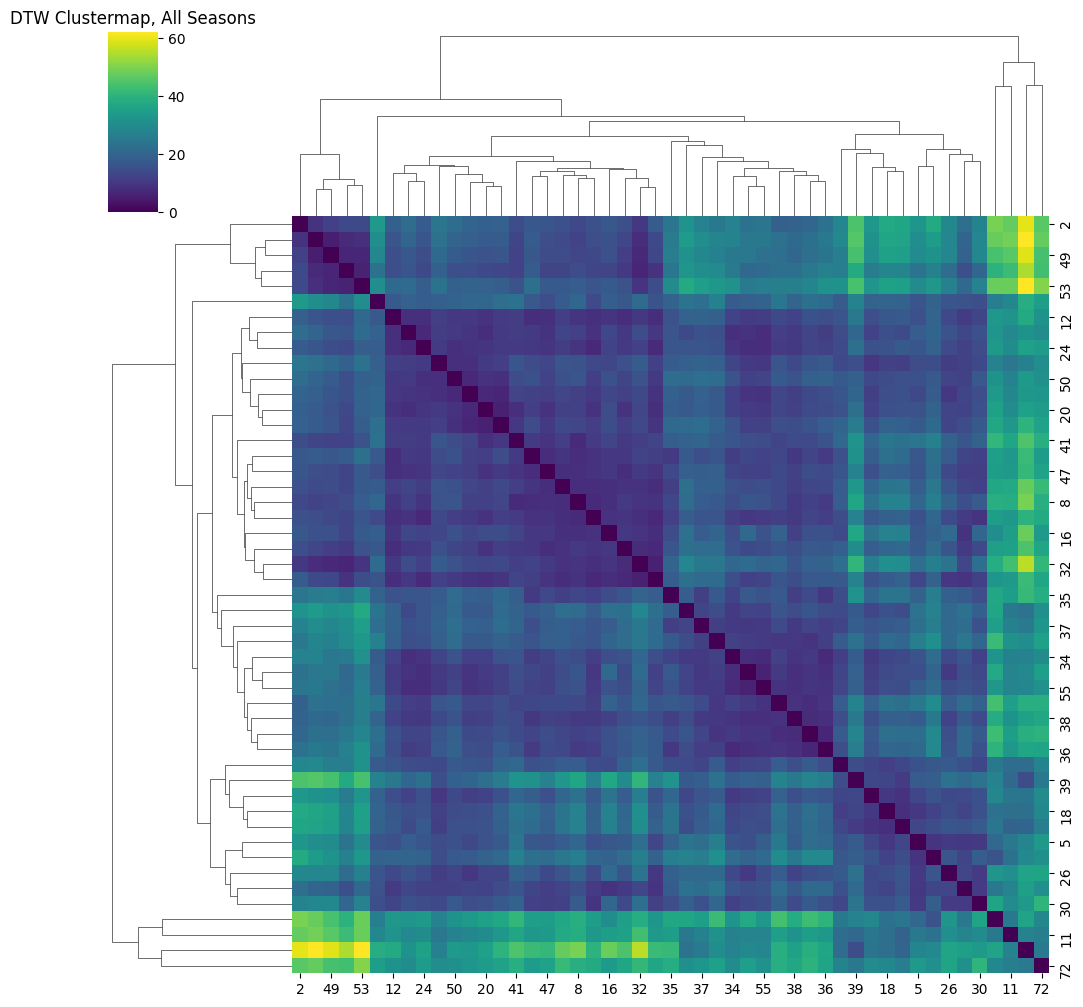

In [32]:
# all seasons, DTW -- states w/ Inf DTW values dropped
plot_dtw_clustermap(dtw_clean, "DTW Clustermap, All Seasons")

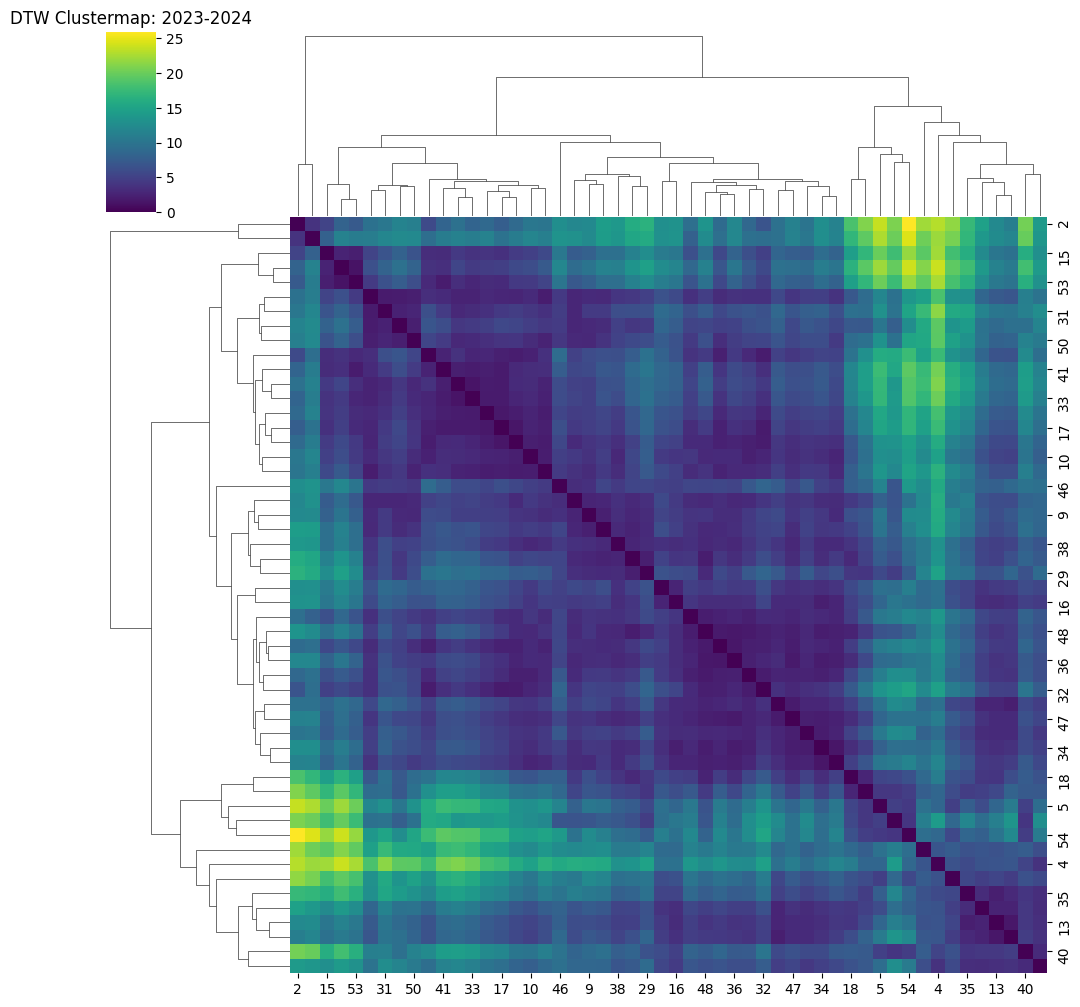

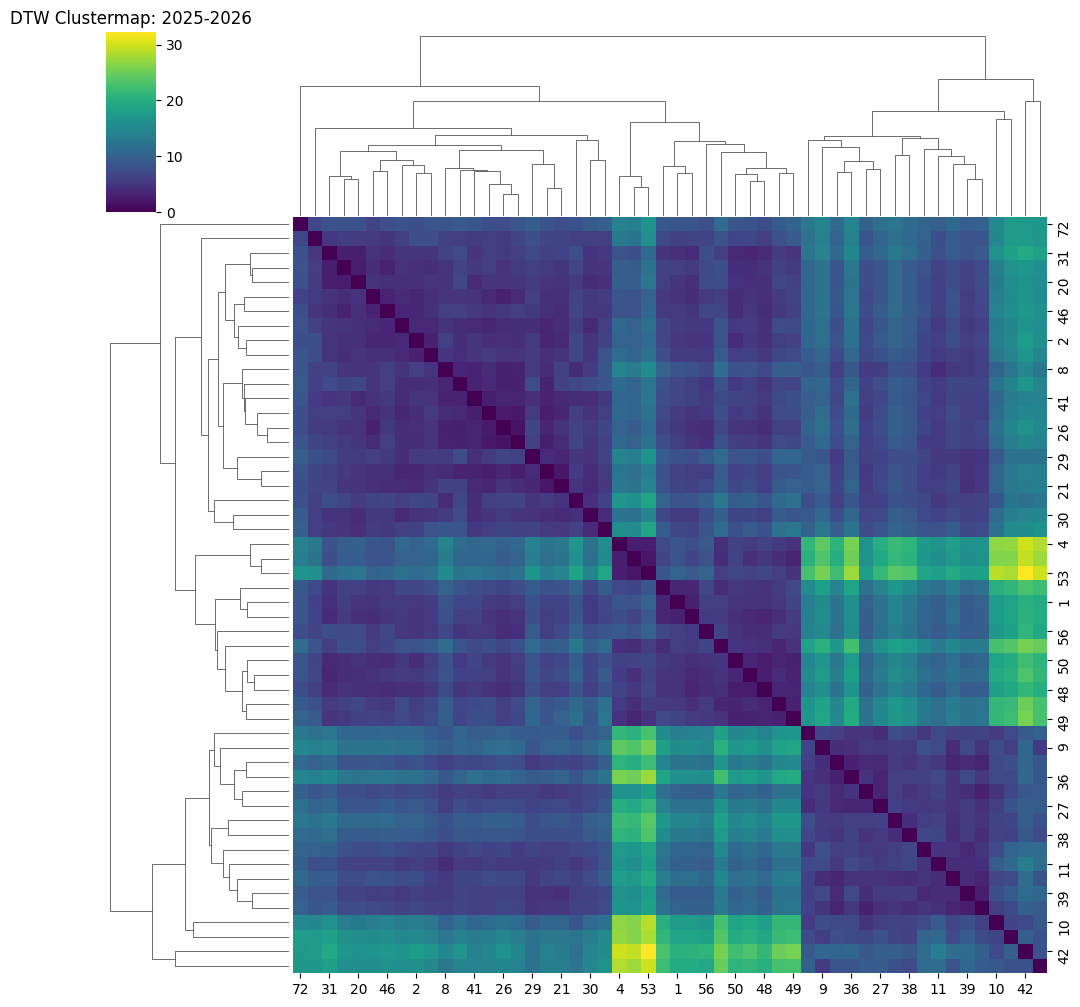

In [33]:
# individual seasons, no dropping of problematic states
# season 2 (24-25) does not plot as a result

plot_dtw_clustermap(dtw_df_1, "DTW Clustermap: 2023-2024")
# plot_dtw_clustermap(dtw_df_2, "DTW Clustermap: 2024-2025")
plot_dtw_clustermap(dtw_df_3, "DTW Clustermap: 2025-2026")

In [34]:
### SMOOTHING

# start with EMA on the whole ts
ts_smooth = ts.ewm(min_periods=1, halflife=2).mean() # min_periods needed or not? axis=0?
# places greater emphasis on more recent datapoints

# now perform DTW
X_smooth = ts_smooth.T.values
dtw_matrix_smooth = cdist_dtw(X_smooth, sakoe_chiba_radius=5)
dtw_matrix_smooth

array([[ 0.        , 13.36684454, 25.72581744, ...,  9.09104428,
        11.73549946, 29.41420523],
       [13.36684454,  0.        , 44.54620936, ..., 20.31245071,
        28.34614045, 43.63860989],
       [25.72581744, 44.54620936,  0.        , ..., 26.09102924,
        15.2517441 , 26.62194031],
       ...,
       [ 9.09104428, 20.31245071, 26.09102924, ...,  0.        ,
        13.72244285, 25.46270715],
       [11.73549946, 28.34614045, 15.2517441 , ..., 13.72244285,
         0.        , 26.2793922 ],
       [29.41420523, 43.63860989, 26.62194031, ..., 25.46270715,
        26.2793922 ,  0.        ]], shape=(52, 52))

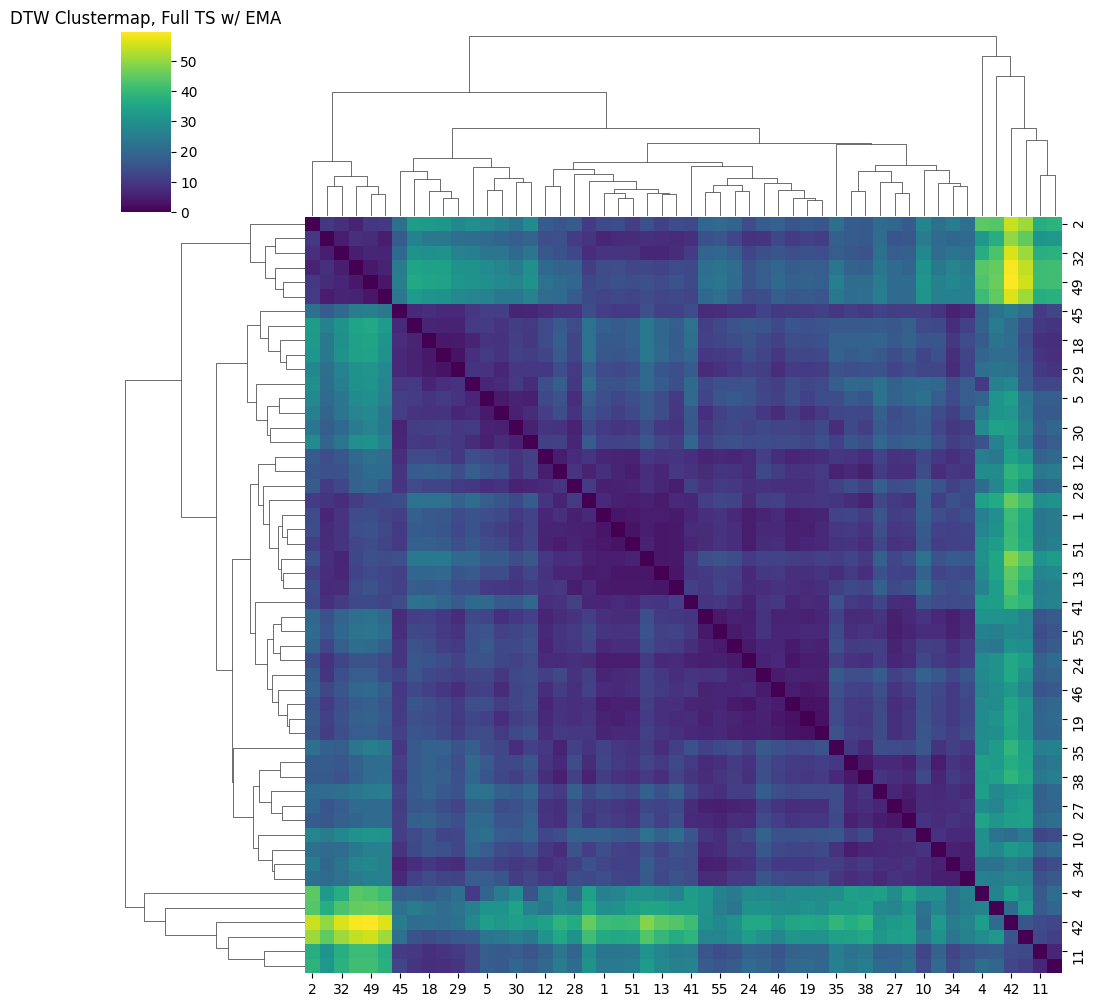

In [35]:
dtw_df_smooth = pd.DataFrame(dtw_matrix_smooth, index=state_ids,columns=state_ids)
plot_dtw_clustermap(dtw_df_smooth, "DTW Clustermap, Full TS w/ EMA")

# EMA smoothing eliminated the inf vals we get from running DTW on all seasons -- so no need to drop those states

In [36]:
# smooth and calculate DTW per season

def run_dtw_smooth(df):
    ts = df.pivot(index="date", columns="fips_state", values="flu_per100k") # make axes aligned

    ts_smooth = ts.ewm(min_periods=1, halflife=2).mean()

    X_smooth = ts_smooth.T.values
    dtw_matrix_smooth = cdist_dtw(X_smooth, sakoe_chiba_radius=3) # for 5 -- df 1 & 2 were very dark all around, like too much similarity -- because it's allowing for time shifts of up to 5 weeks
    
    return pd.DataFrame(dtw_matrix_smooth, index=state_ids,columns=state_ids)

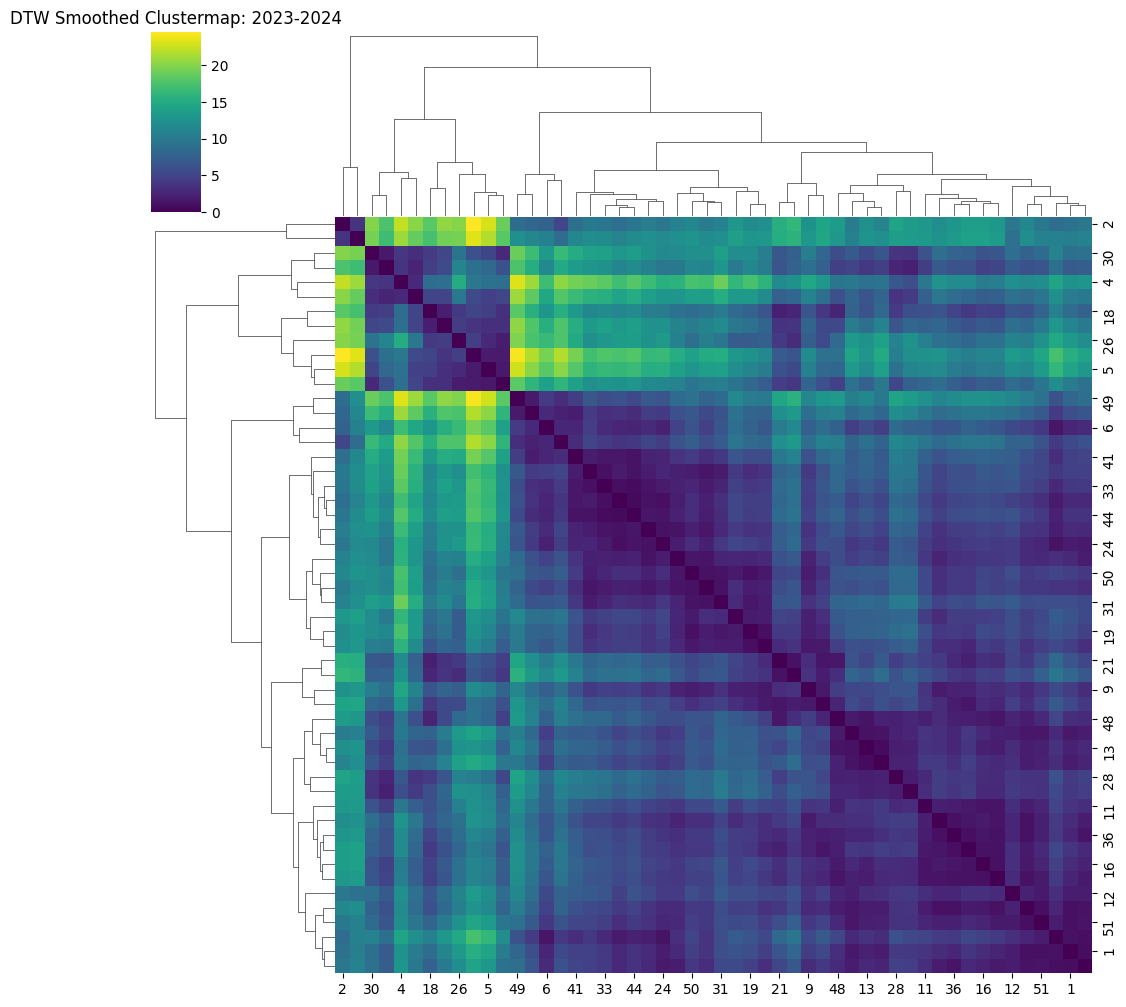

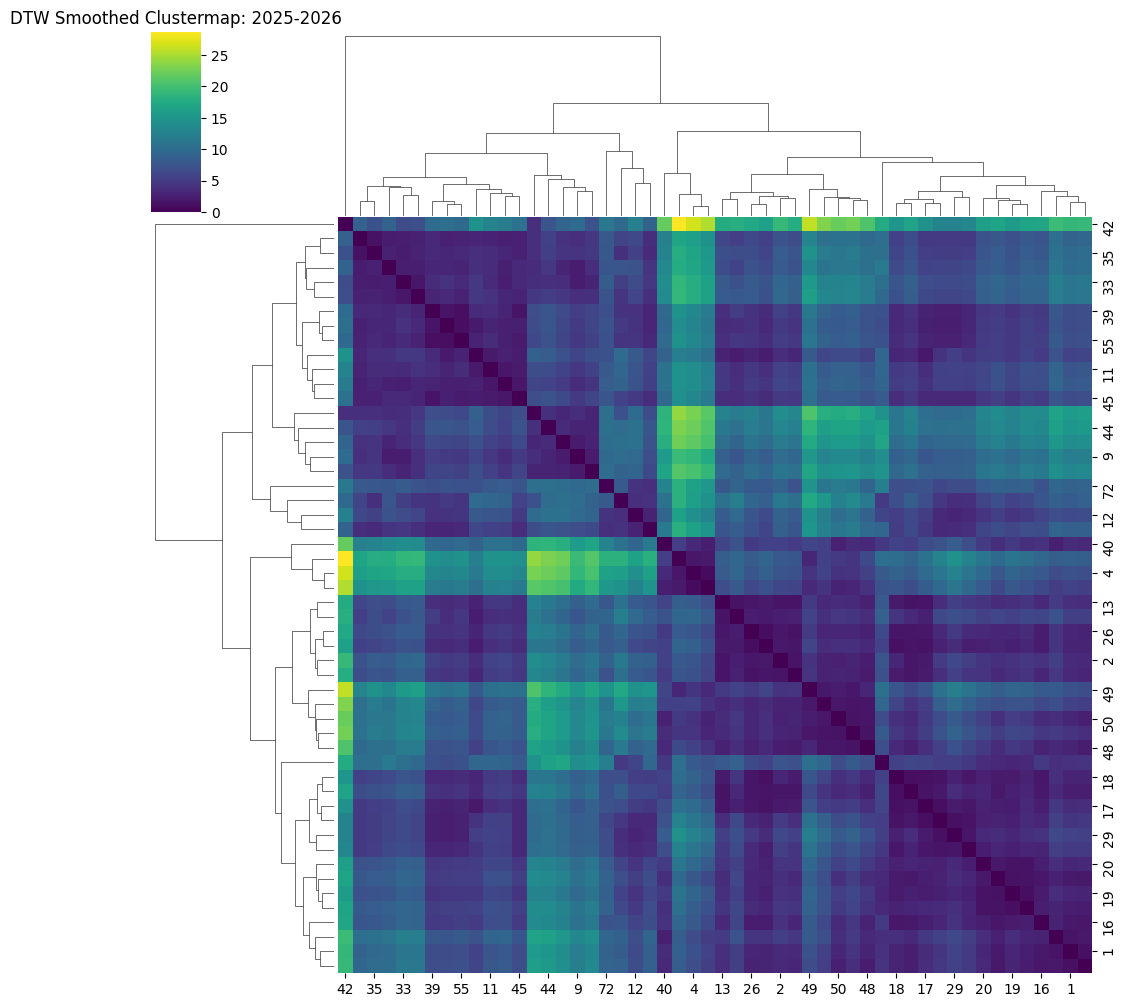

In [37]:
dtw_df_1_smooth = run_dtw_smooth(df_1)
dtw_df_2_smooth = run_dtw_smooth(df_2)
dtw_df_3_smooth = run_dtw_smooth(df_3)

# now 24-25 breaks again
plot_dtw_clustermap(dtw_df_1_smooth, "DTW Smoothed Clustermap: 2023-2024")
# plot_dtw_clustermap(dtw_df_2_smooth, "DTW Smoothed Clustermap: 2024-2025")
plot_dtw_clustermap(dtw_df_3_smooth, "DTW Smoothed Clustermap: 2025-2026")


In [38]:
# let's plot the time series - raw + EMS
ts_t = ts.T

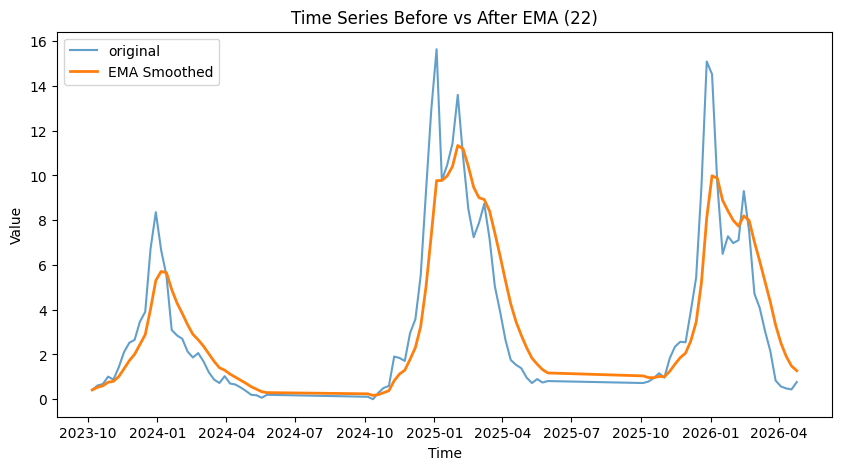

In [39]:
ts_smooth_t = ts_smooth.T
idx = ts_t.index[18] # NY is fips code 36
# index 18 --> fips 22 (LA) (used often in slide deck for an understanding of the smoothing methods work, as it's very jagged)

plt.figure(figsize=(10, 5))
plt.plot(ts_t.loc[idx], label="original", alpha=0.7)
plt.plot(ts_smooth_t.loc[idx], label="EMA Smoothed", linewidth=2)

plt.title(f"Time Series Before vs After EMA ({idx})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

In [40]:
# EMA is working, but it's introducing a delay.
# try GAM instead

In [41]:
#%pip install pygam

In [42]:
from pygam import LinearGAM, s

In [43]:
ts.isna().sum().sum()

np.int64(7)

In [44]:
def smooth_ts_gam(ts, n_splines=50, min_obs=10, lam=0.05):
    # for output:
    ts_smooth = pd.DataFrame(index=ts.index, columns=ts.columns, dtype=float)
    ts_lower = pd.DataFrame(index=ts.index, columns=ts.columns, dtype=float)
    ts_upper = pd.DataFrame(index=ts.index, columns=ts.columns, dtype=float)

    # convert dates
    t = (ts.index - ts.index.min()).days.values.reshape(-1,1)

    for state in ts.columns:
        y = ts[state].values

        mask = ~np.isnan(y)
        if mask.sum() < min_obs:
            continue

        gam = LinearGAM(s(0, n_splines=n_splines), lam=lam).fit(t[mask], y[mask])

        preds = gam.predict(t)

        # conf bands added for future sensitivity analysis
        intervals = gam.prediction_intervals(t, width=0.8)

        ts_smooth[state] = preds
        ts_lower[state] = intervals[:, 0]
        ts_upper[state] = intervals[:, 1]

    return ts_smooth, ts_lower, ts_upper

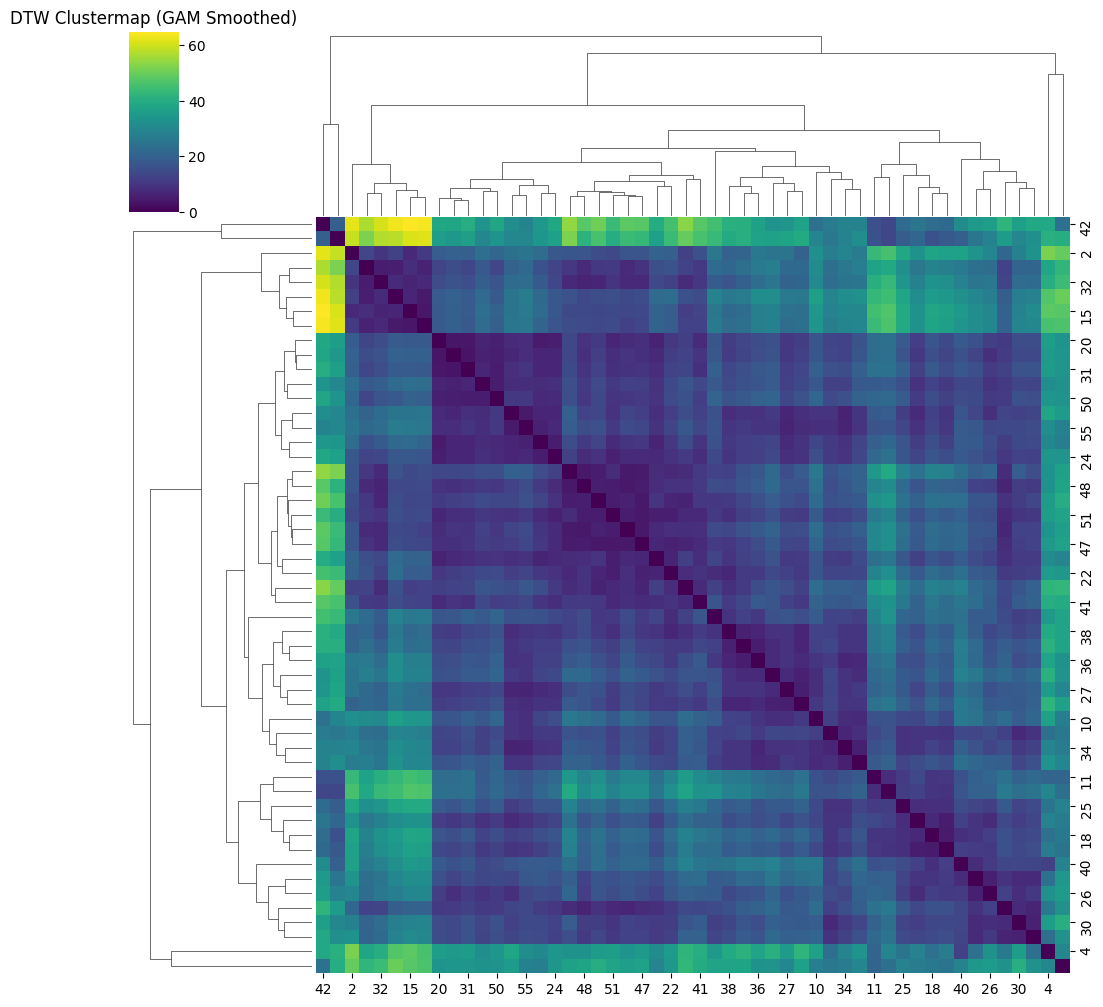

In [45]:
ts_gam, *_ = smooth_ts_gam(ts, n_splines=75, lam=0.1) # final chosen values

X = ts_gam.T.values
dtw_matrix_gam = cdist_dtw(X, sakoe_chiba_radius=5)

dtw_df_gam = pd.DataFrame(dtw_matrix_gam, index=state_ids, columns=state_ids)

plot_dtw_clustermap(dtw_df_gam, "DTW Clustermap (GAM Smoothed)")

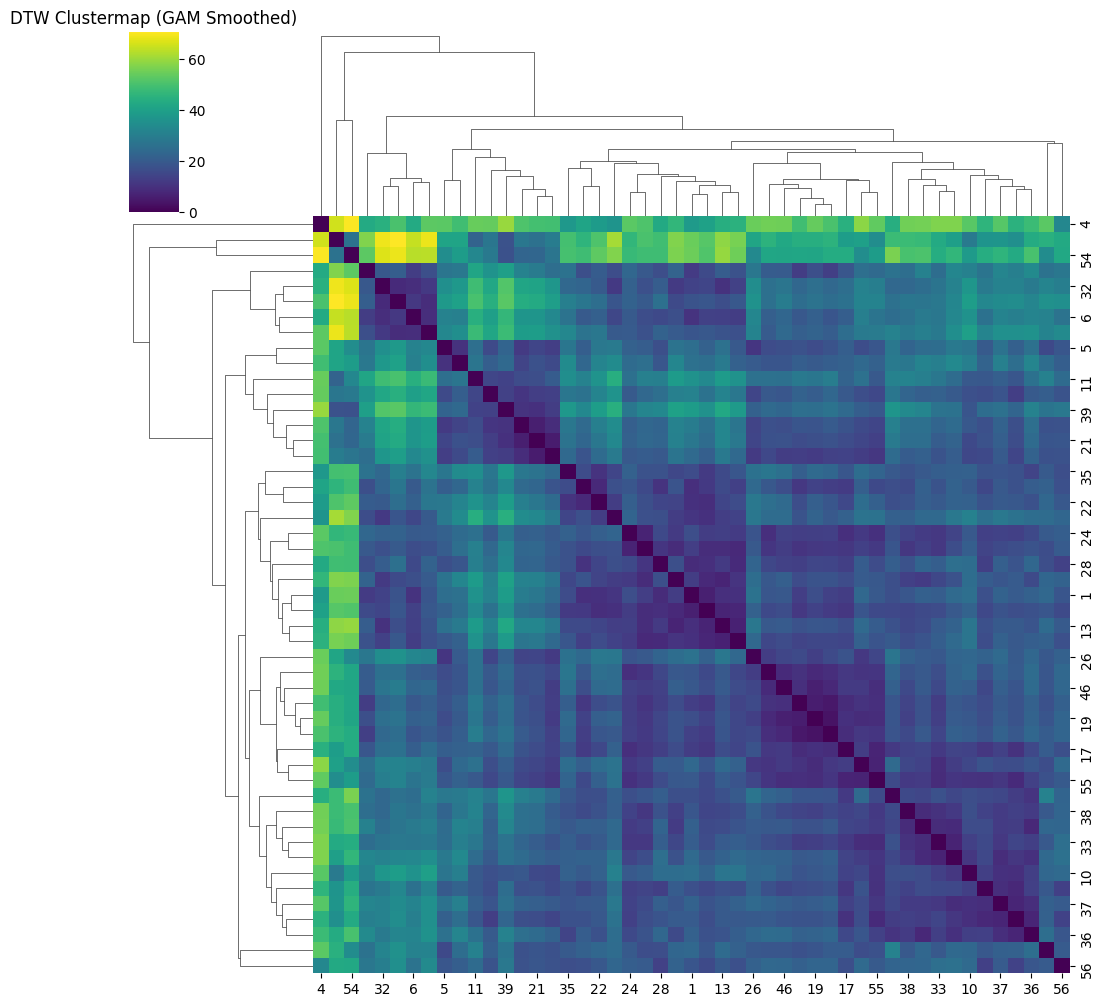

In [46]:
# drop alaska, hawaii, american samoa, guam, CNMI, PR, US virgin islands
ts_clean = ts.drop(columns=[c for c in [2, 15, 60, 66, 69, 72, 78] if c in ts.columns])

ts_gam, *_ = smooth_ts_gam(ts_clean, n_splines=75, lam=0.1)

X = ts_gam.T.values
dtw_matrix_gam = cdist_dtw(X, sakoe_chiba_radius=1)

state_ids_clean = ts_clean.columns.tolist()
dtw_df_gam = pd.DataFrame(dtw_matrix_gam, index=state_ids_clean, columns=state_ids_clean)

plot_dtw_clustermap(dtw_df_gam, "DTW Clustermap (GAM Smoothed)")

In [47]:
# try GAM DTW by season

def run_dtw_gam(df):
    ts = df.pivot(index="date", columns="fips_state", values="flu_per100k")
    ts_gam, *_ = smooth_ts_gam(ts)
    
    X = ts_gam.T.values
    dtw_matrix = cdist_dtw(X, sakoe_chiba_radius=5)
    
    return pd.DataFrame(dtw_matrix, index=ts.columns, columns=ts.columns)

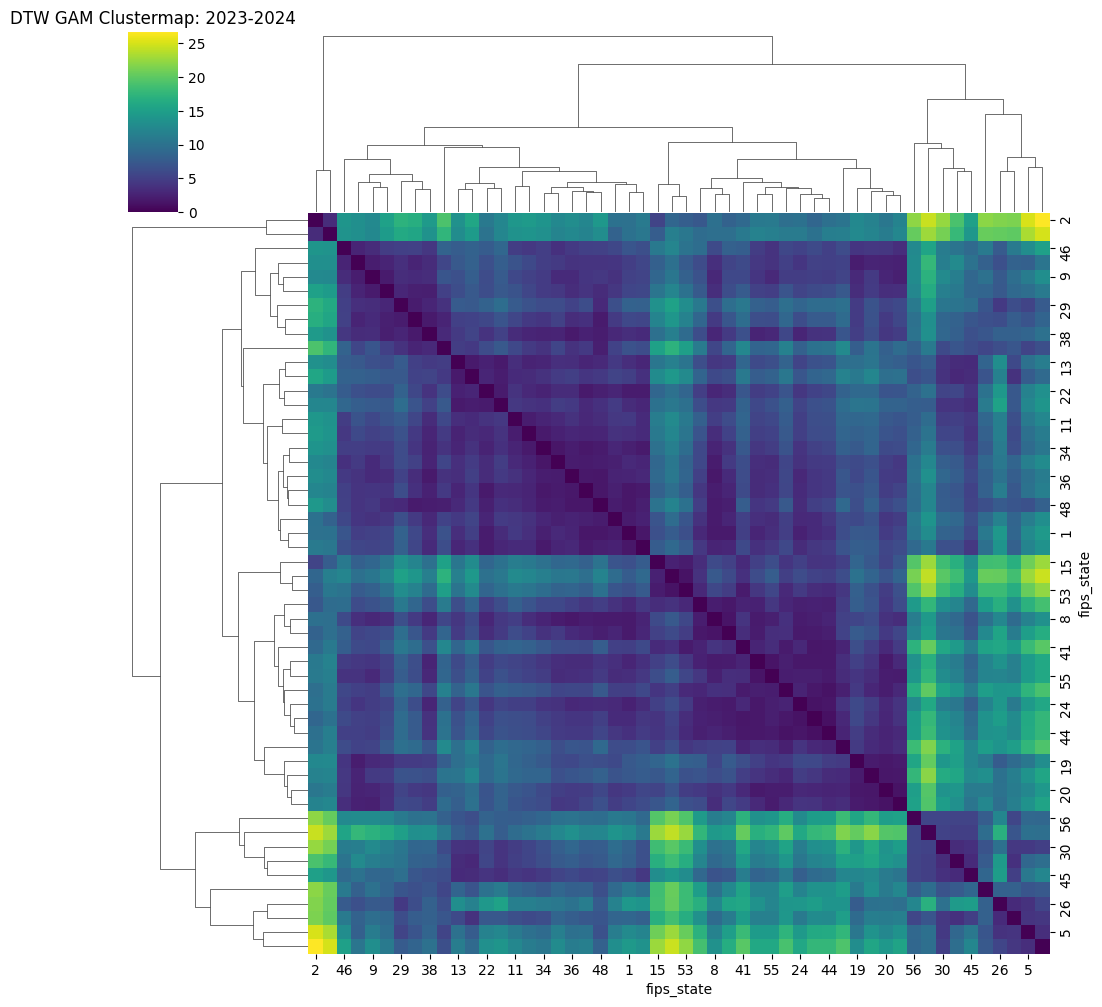

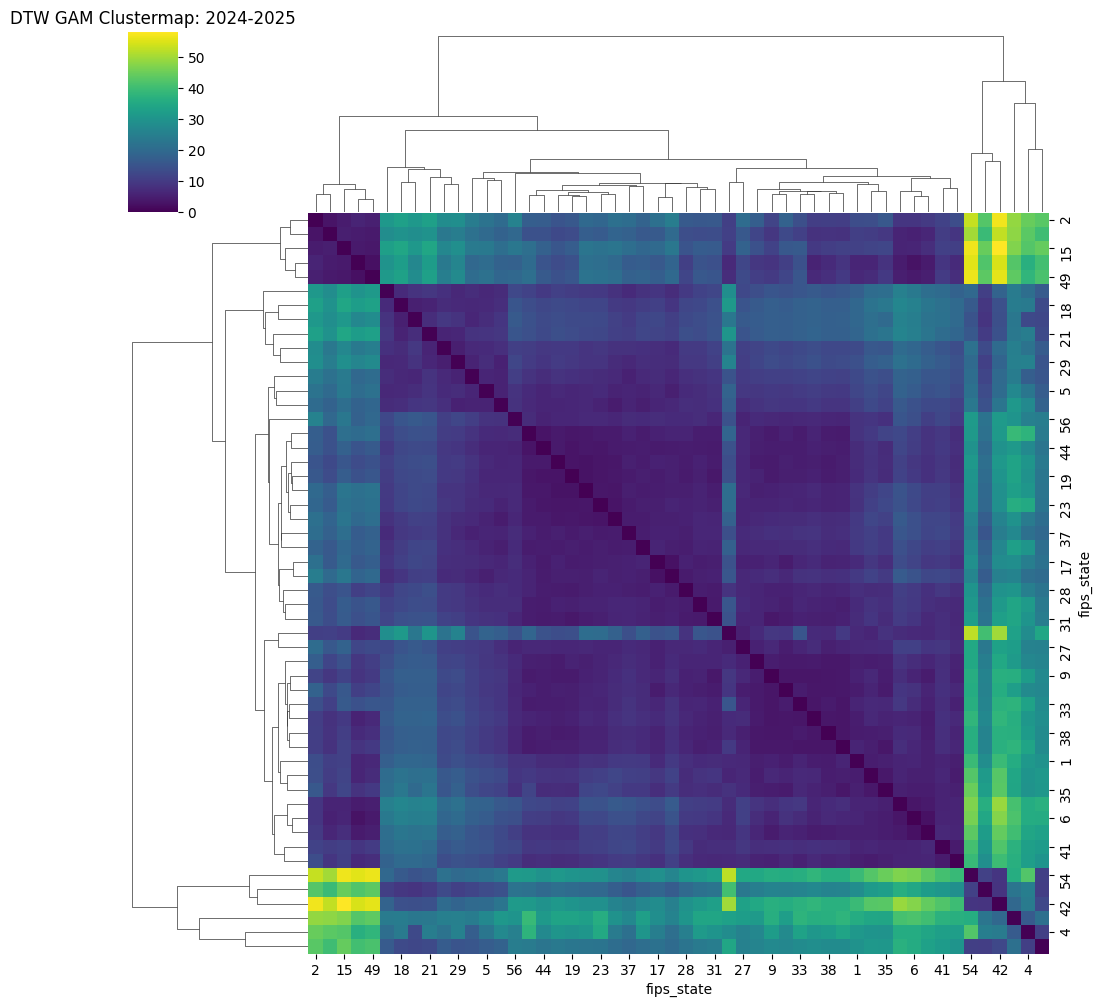

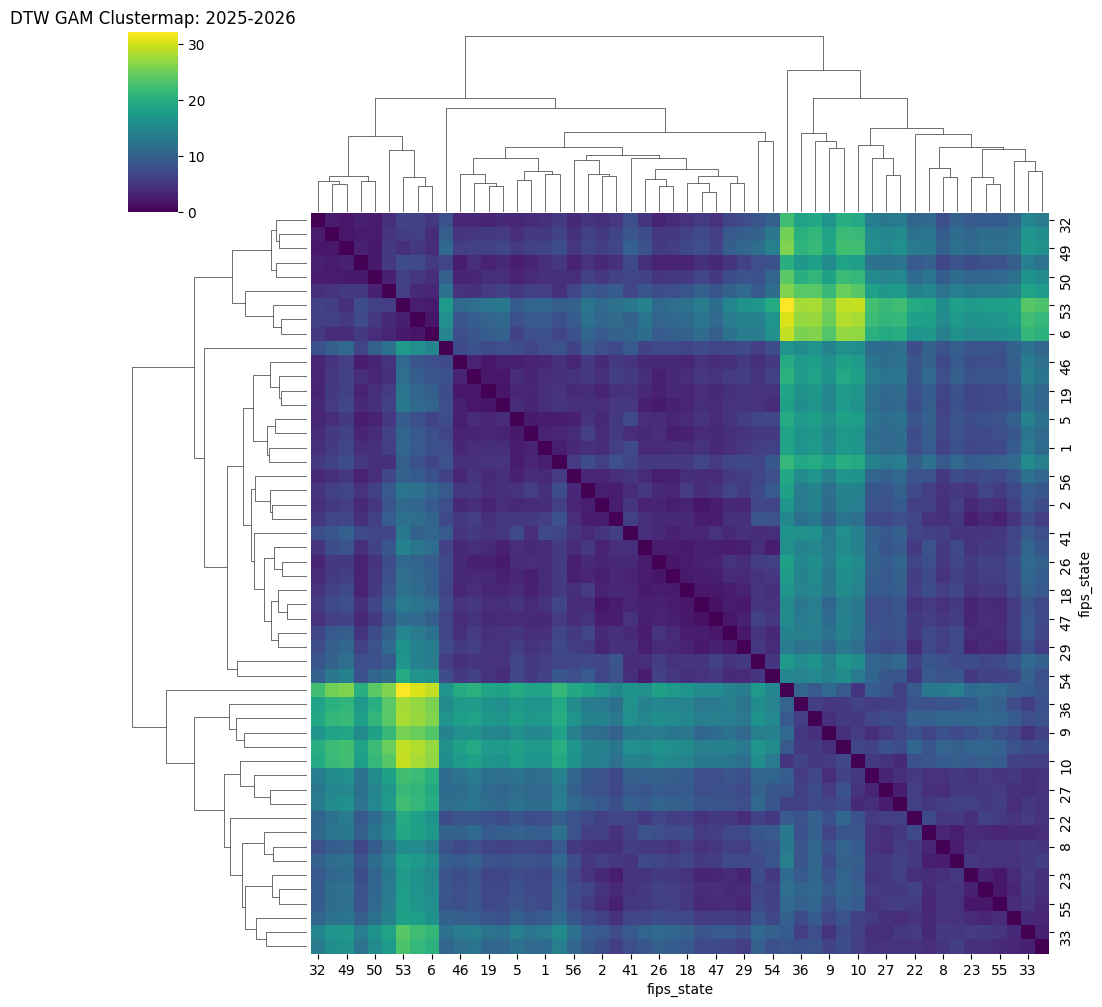

In [48]:
dtw_df_1_gam = run_dtw_gam(df_1)
dtw_df_2_gam = run_dtw_gam(df_2)
dtw_df_3_gam = run_dtw_gam(df_3)


plot_dtw_clustermap(dtw_df_1_gam, "DTW GAM Clustermap: 2023-2024")
plot_dtw_clustermap(dtw_df_2_gam, "DTW GAM Clustermap: 2024-2025")
plot_dtw_clustermap(dtw_df_3_gam, "DTW GAM Clustermap: 2025-2026")

In [49]:
# looks very interesting
# now let's look at the time series plots

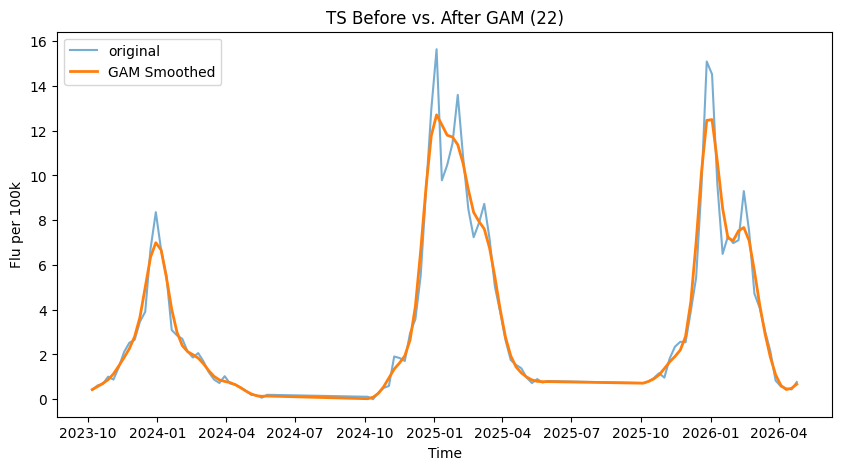

In [50]:
ts_gam_t = ts_gam.T
idx = ts_t.index[18] # LA

plt.figure(figsize=(10, 5))
plt.plot(ts_t.loc[idx], label="original", alpha=0.6)
plt.plot(ts_gam_t.loc[idx], label="GAM Smoothed", linewidth=2)

plt.title(f"TS Before vs. After GAM ({idx})")
plt.xlabel("Time")
plt.ylabel("Flu per 100k")
plt.legend()
plt.show() # no more delay

In [51]:
# do a sensititivity analysis w/ lambda and n_splines
# add confidence bands

lams = [0.01, 0.05, 0.1]
splines = [25, 50, 75]

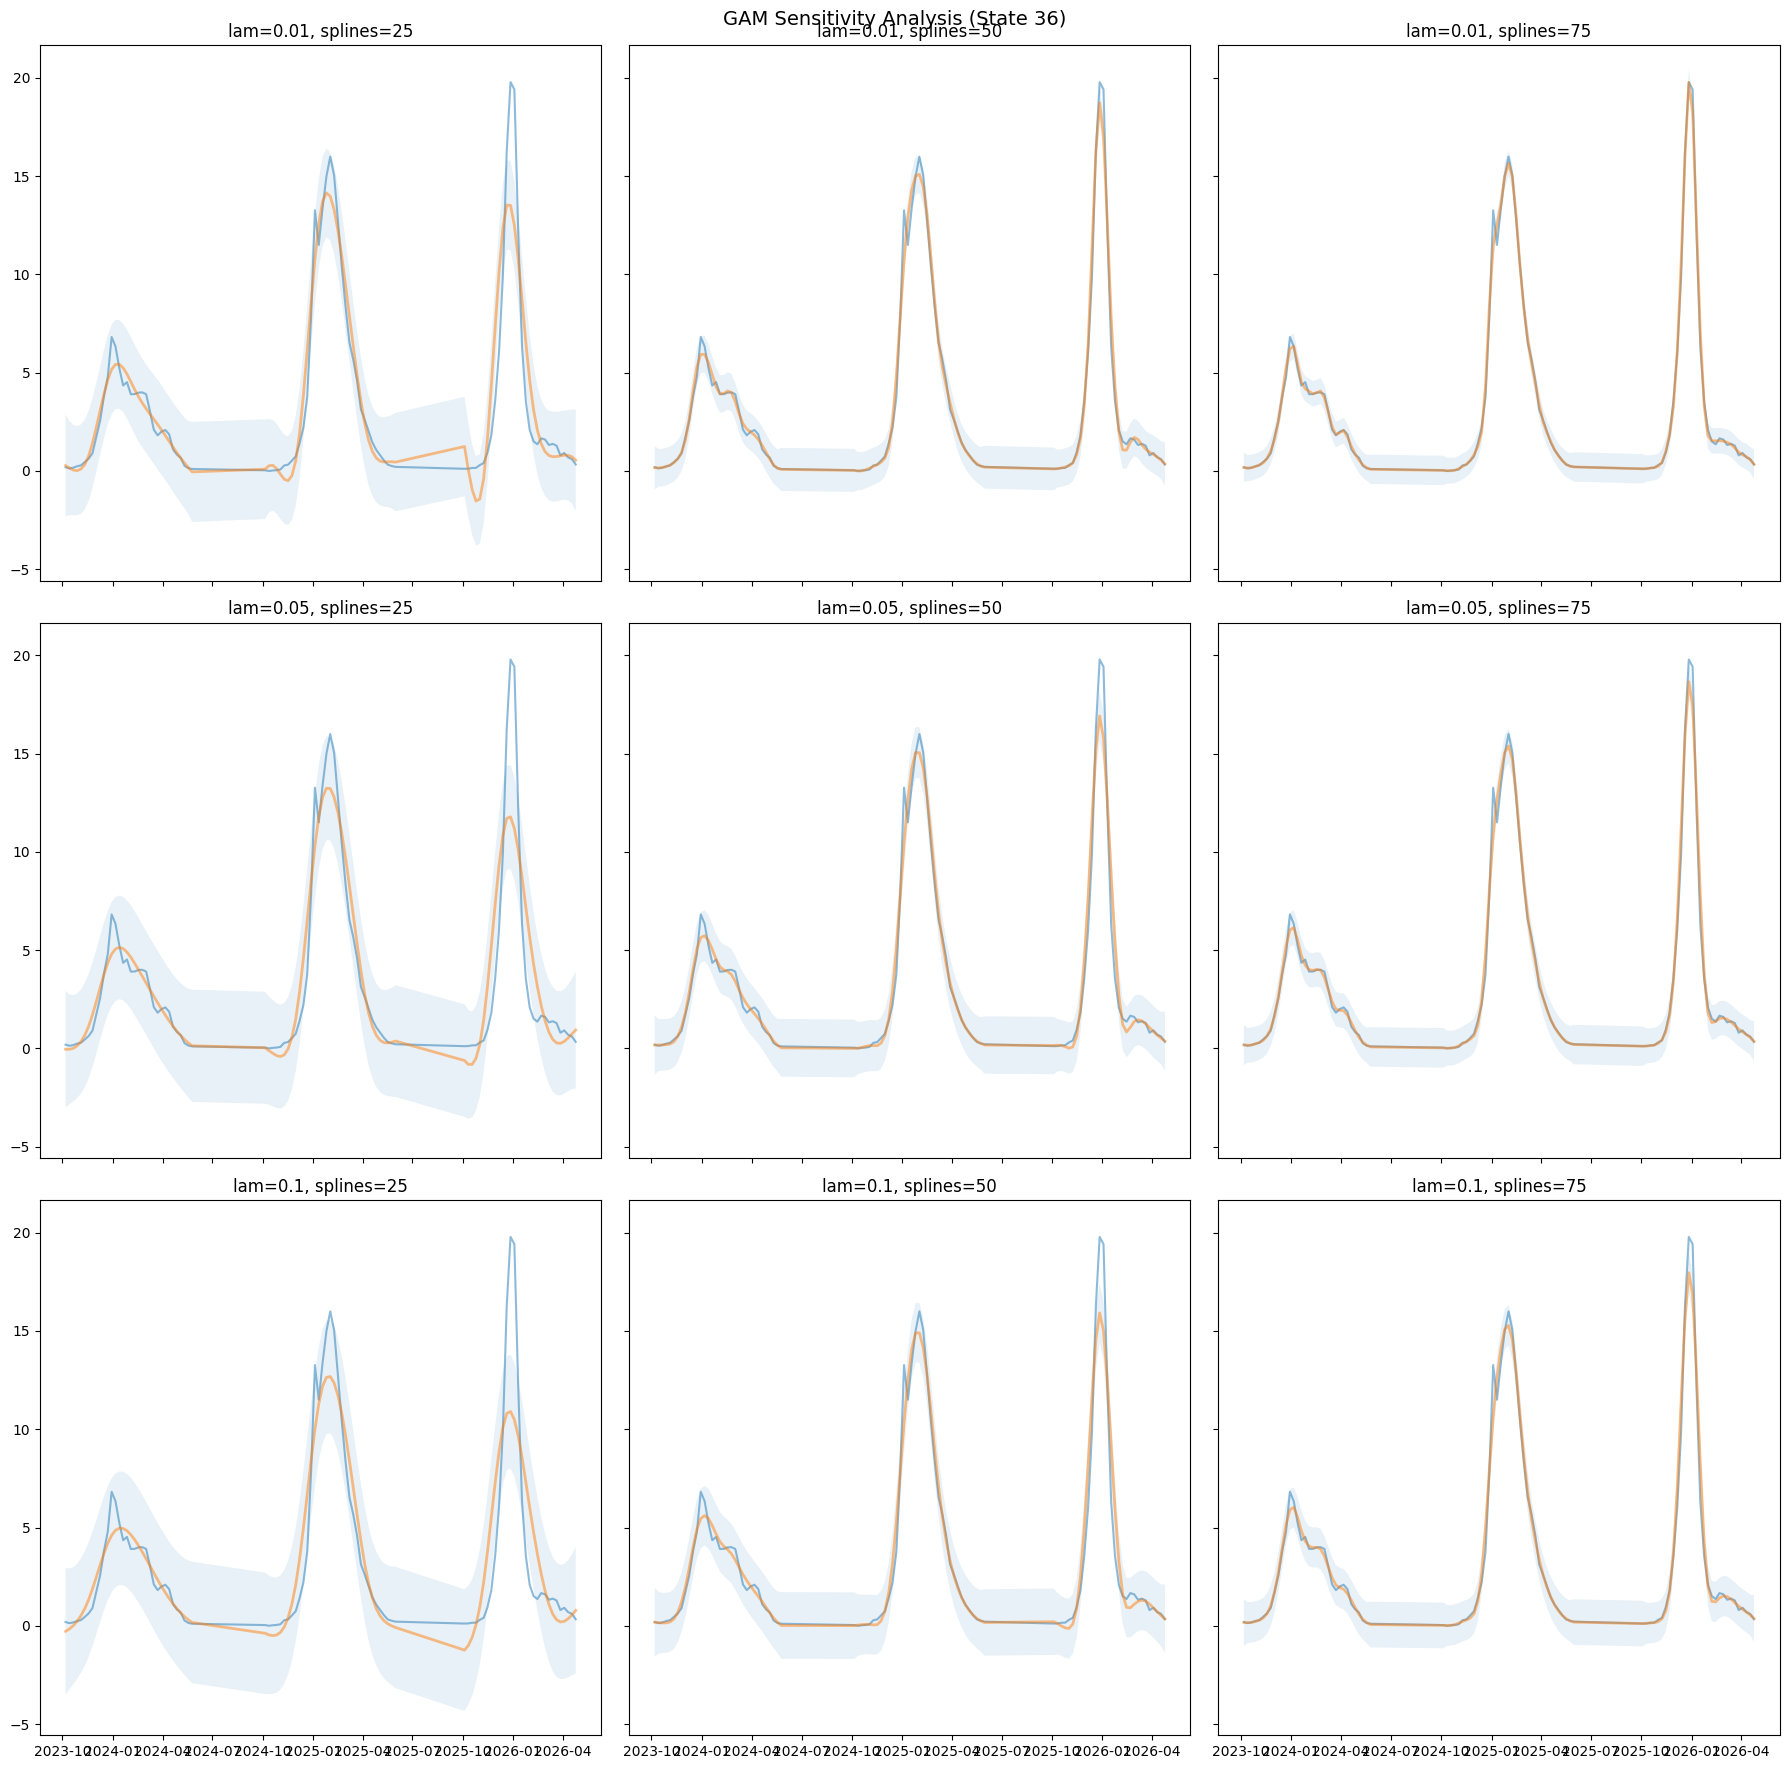

In [52]:
idx = ts.columns[32] # just a random FIPS code - can adjust

fig,axes = plt.subplots(len(lams), len(splines), figsize=(18,18),sharex=True, sharey=True)

for i, lam in enumerate(lams):
    for j, n_splines in enumerate(splines):

        ts_gam, ts_lower, ts_upper = smooth_ts_gam(ts, n_splines=n_splines, lam=lam)

        axes[i,j].plot(ts.index, ts[idx], label="original", alpha=0.5)
        axes[i,j].plot(ts.index, ts_gam[idx], label="GAM smoothed", alpha=0.5, linewidth=2)

        # confidence band
        axes[i, j].fill_between(
            ts.index,
            ts_lower[idx],
            ts_upper[idx],
            alpha=0.1
        )

        axes[i, j].set_title(f"lam={lam}, splines={n_splines}")


plt.suptitle(f"GAM Sensitivity Analysis (State {idx})", fontsize=14)
plt.tight_layout()
plt.show()






In [53]:
# 0.1, 75 look good
# BUT: re-run now that we're z-scoring -- adjust the parameters

In [54]:
### PLOT CLUSTERS

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

def get_clusters(dtw_df, k=5):
    condensed = squareform(dtw_df.values)
    linkage_mat = linkage(condensed, method="average") # hierarchical clustering
    labels = fcluster(linkage_mat, k, criterion="maxclust")
    
    return pd.Series(labels, index=dtw_df.index)

cluster_labels = get_clusters(dtw_df_gam, k=5)

In [55]:
#%pip install geopandas

In [56]:
import geopandas as gpd

url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_5m.zip" # US census shapefile, moderate level of resolution
gdf = gpd.read_file(url)

In [57]:
gdf.head(6)

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,31,01779792,0400000US31,31,NE,Nebraska,00,198956658395,1371829134,"POLYGON ((-104.05351 41.15726, -104.05267 41.2..."
1,53,01779804,0400000US53,53,WA,Washington,00,172112588220,12559278850,"MULTIPOLYGON (((-122.32834 48.02134, -122.3217..."
2,35,00897535,0400000US35,35,NM,New Mexico,00,314196306401,728776523,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
3,46,01785534,0400000US46,46,SD,South Dakota,00,196346981786,3382720225,"POLYGON ((-104.0577 44.99743, -104.05021 44.99..."
4,48,01779801,0400000US48,48,TX,Texas,00,676653171537,19006305260,"POLYGON ((-106.64548 31.89867, -106.64084 31.9..."
5,06,01779778,0400000US06,06,CA,California,00,403503931312,20463871877,"MULTIPOLYGON (((-118.60338 33.4781, -118.59878..."


In [58]:
# match fips codes
gdf["fips_state"] = gdf["STATEFP"].astype(int)

# merge
cluster_df = cluster_labels.reset_index()
cluster_df.columns = ["fips_state", "cluster"]

gdf = gdf.merge(cluster_df, on="fips_state", how="left")

<Figure size 1200x800 with 0 Axes>

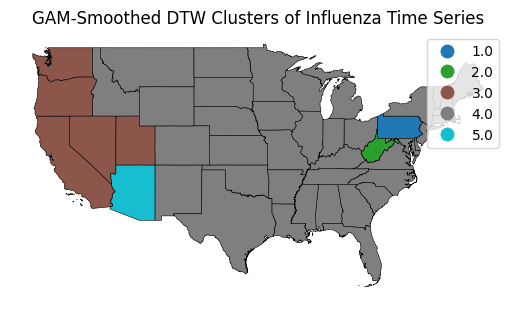

In [59]:
# plot clusters!

fips_to_drop = [
    2, 15,     # AK, HI
    60, 66, 69, 72, 78 # AS, GU, MP, PR, VI
]
# would be interesting to look at them later. for now, adding them in shrinks the US mainland -- would need to adjust plot sizing

gdf = gdf[~gdf['fips_state'].isin(fips_to_drop)]

gdf = gdf.reset_index(drop=True)


plt.figure(figsize=(12,8))

gdf.plot(column="cluster",
         categorical=True,
         legend=True,
         edgecolor="black",
         cmap="tab10",
         linewidth=0.4)


plt.axis("off")
plt.title("GAM-Smoothed DTW Clusters of Influenza Time Series")
plt.show()

In [60]:
# create a func to look at individual time series easier --> understand the clustering 
def plot_ts_gam(idx):
    ts_gam_t = ts_gam.T
    idx = ts_t.index[idx] 

    plt.figure(figsize=(10, 5))
    plt.plot(ts_t.loc[idx], label="original", alpha=0.6)
    plt.plot(ts_gam_t.loc[idx], label="GAM Smoothed", linewidth=2)

    plt.title(f"TS Before vs. After GAM ({idx})")
    plt.xlabel("Time")
    plt.ylabel("Flu per 100k")
    plt.legend()
    plt.show()

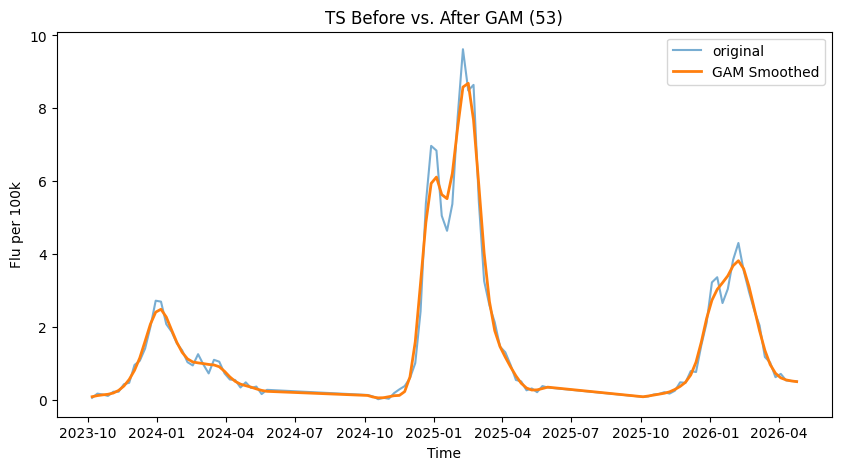

In [61]:
# look at WA + CA time series

# WA
plot_ts_gam(idx=47) # fips code 53

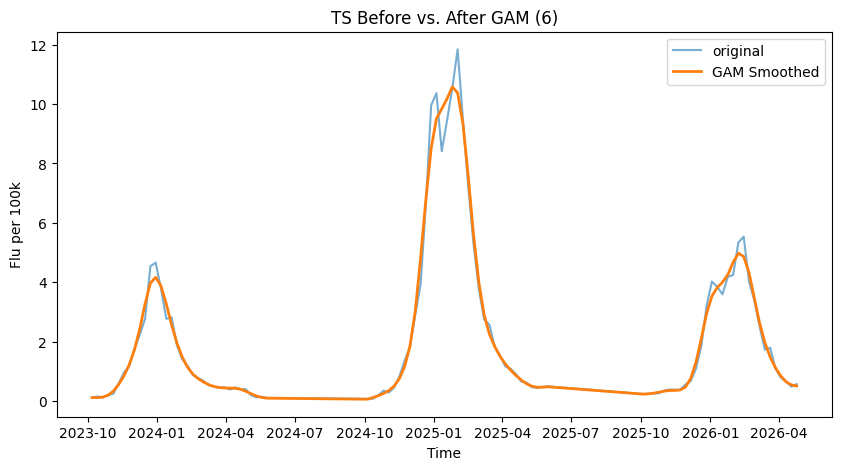

In [62]:
# CA
plot_ts_gam(idx=4) # fips code 06

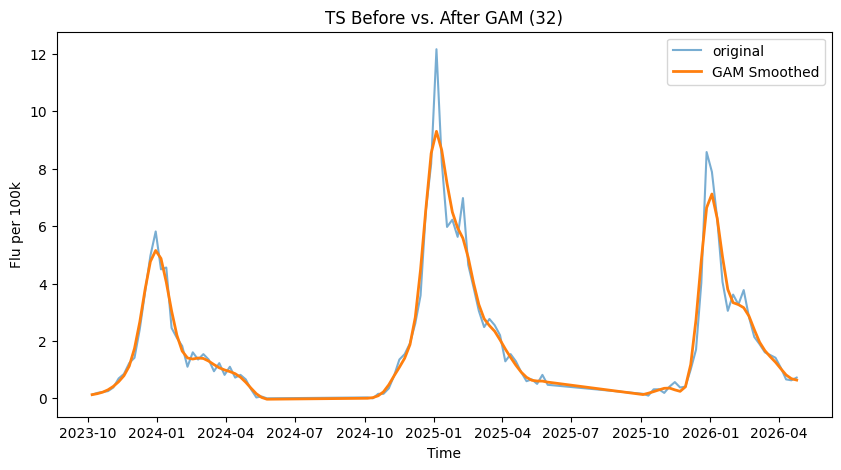

In [63]:
# NV
plot_ts_gam(idx=28) # fips code 32

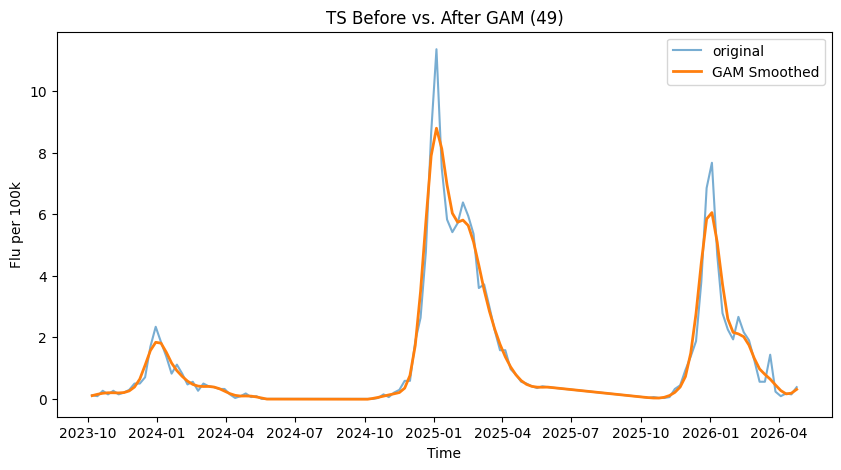

In [64]:
# UT
plot_ts_gam(idx=44) # fips code 49

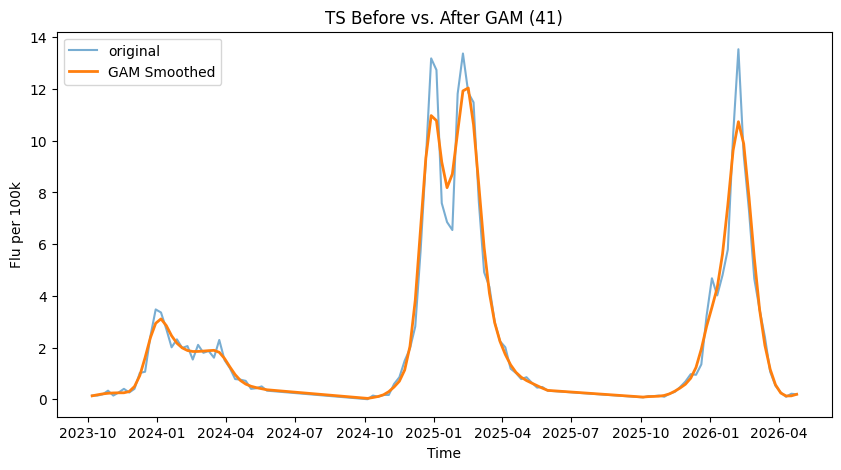

In [65]:
# why not OR?
plot_ts_gam(idx=37) # fips code 41

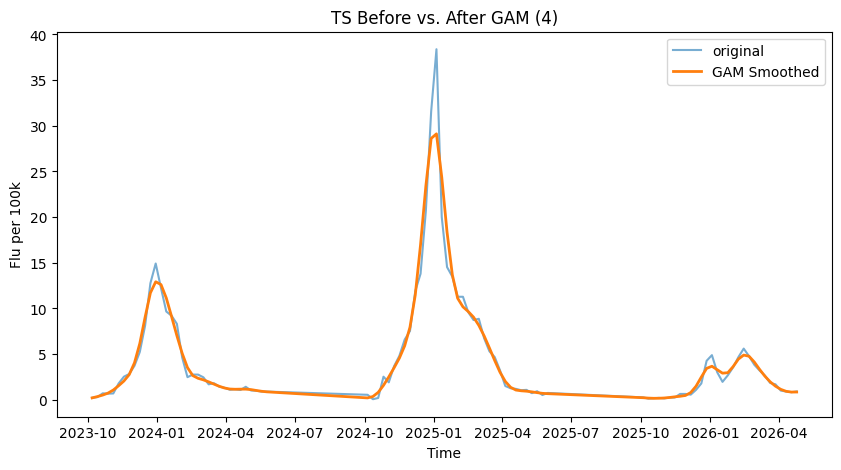

In [66]:
# AZ
plot_ts_gam(idx=2) # fips code 04

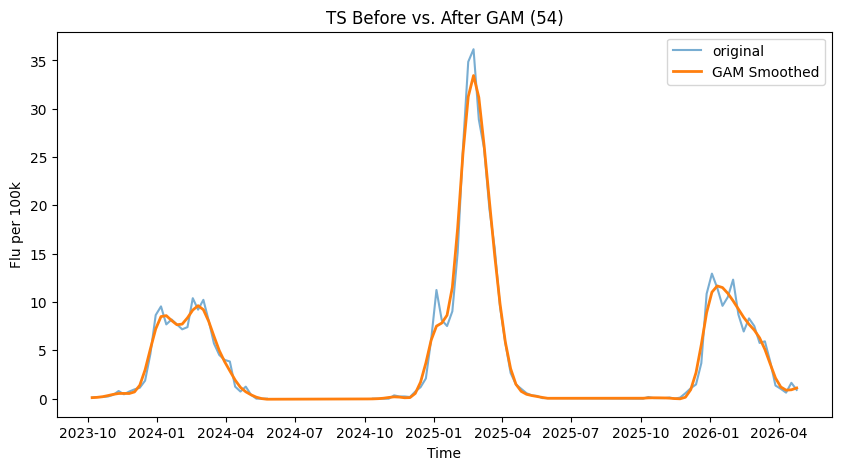

In [67]:
# WV 

plot_ts_gam(idx=48) # fips code 54

In [68]:
# do we want to try accounting for time shifts now, rather than magnitude?

# maxP - guarantees spatial continuity. covariates. 

In [69]:
## try Z-Score Normalization (removes magnitude factor, preserves shape + time), then GAM smooth, then find Euclidean distances

from scipy.stats import zscore
from scipy.spatial.distance import cdist



In [70]:
# create z-normalized ts
ts_zscore = ts.apply(zscore, nan_policy="omit", axis=0)

In [71]:
# gam smooth the z-normalized ts
ts_zscore_gam, ts_zscore_lower, ts_zscore_upper = smooth_ts_gam(ts_zscore, n_splines=100, lam=0.1)

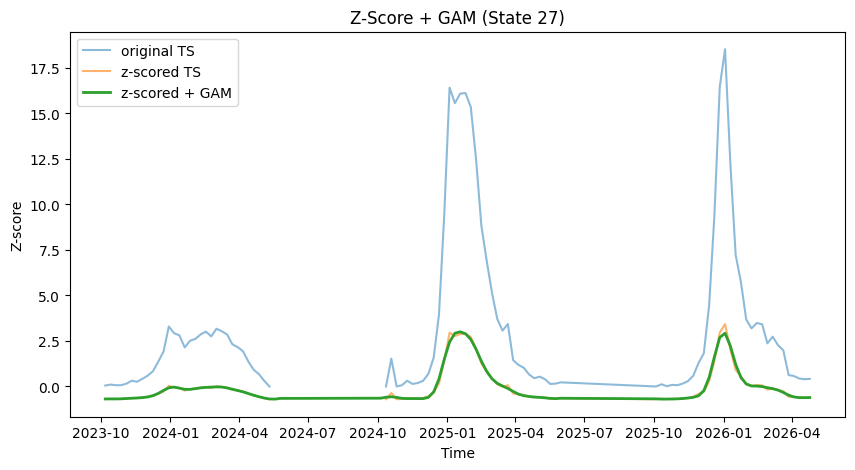

In [72]:
# sanity check plot
idx = ts.columns[23]

plt.figure(figsize=(10, 5))
plt.plot(ts.index, ts[idx], label="original TS", alpha=0.5)
plt.plot(ts.index, ts_zscore[idx], label="z-scored TS", alpha=0.6)
plt.plot(ts.index, ts_zscore_gam[idx], label="z-scored + GAM", linewidth=2)
plt.title(f"Z-Score + GAM (State {idx})")
plt.xlabel("Time")
plt.ylabel("Z-score")
plt.legend()
plt.show()

# too smooth? try lam=0.05? 
# try using mean & SD of global?

In [73]:
ts_zscore_gam

fips_state,1,2,4,5,6,8,9,10,11,12,...,47,48,49,50,51,53,54,55,56,72
date,,,,,,,,,,,,,,,,,,,,,
2023-10-07,-0.736776,-0.411991,-0.696922,-0.712160,-0.769781,-0.792054,-0.710117,-0.655436,-0.581986,-0.785143,...,-0.781951,-0.806001,-0.662658,-0.720498,-0.640547,-0.766499,-0.713767,-0.678743,-0.611847,-0.388705
2023-10-14,-0.715800,-0.085772,-0.670357,-0.716867,-0.768404,-0.777457,-0.715996,-0.669014,-0.575760,-0.763076,...,-0.754213,-0.748812,-0.642769,-0.697203,-0.611196,-0.742804,-0.710702,-0.692914,-0.670502,-0.364336
2023-10-21,-0.698097,0.328471,-0.648681,-0.722060,-0.766115,-0.767897,-0.710574,-0.671705,-0.584175,-0.718099,...,-0.731441,-0.694815,-0.625297,-0.692097,-0.598967,-0.735993,-0.705252,-0.692964,-0.739464,-0.280473
2023-10-28,-0.671346,0.755421,-0.621771,-0.721983,-0.748623,-0.742986,-0.697382,-0.667611,-0.606258,-0.646460,...,-0.718817,-0.636087,-0.616766,-0.697221,-0.597502,-0.733445,-0.691375,-0.679210,-0.792185,-0.184766
2023-11-04,-0.619220,0.993749,-0.566478,-0.707694,-0.696798,-0.667936,-0.683034,-0.664002,-0.621181,-0.550077,...,-0.713376,-0.568489,-0.618576,-0.683802,-0.580923,-0.716476,-0.668888,-0.661635,-0.777129,-0.153973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-28,-0.609019,-0.411420,-0.489093,-0.604384,-0.384917,-0.569083,-0.492793,-0.487958,-0.615957,-0.660391,...,-0.518897,-0.655776,-0.479461,-0.376223,-0.664340,-0.463516,-0.465499,-0.331928,-0.520924,-0.417446
2026-04-04,-0.664978,-0.475354,-0.550489,-0.694437,-0.504751,-0.680961,-0.501225,-0.584698,-0.615888,-0.790561,...,-0.632909,-0.743225,-0.612018,-0.443734,-0.730754,-0.510879,-0.593471,-0.427964,-0.517573,-0.476390
2026-04-11,-0.687650,-0.543119,-0.586300,-0.760181,-0.584582,-0.727490,-0.516276,-0.617343,-0.585108,-0.850316,...,-0.691871,-0.794099,-0.663393,-0.535378,-0.754466,-0.538006,-0.610675,-0.510988,-0.535180,-0.511416


In [74]:
# find euclid distance on the z-scored + GAM smoothed time series'

X_zscore_gam = ts_zscore_gam.T.values  
euclid_matrix = cdist(X_zscore_gam, X_zscore_gam, metric="euclidean")
euclid_df = pd.DataFrame(euclid_matrix, index=ts_zscore_gam.columns, columns=ts_zscore_gam.columns)
euclid_df

fips_state,1,2,4,5,6,8,9,10,11,12,...,47,48,49,50,51,53,54,55,56,72
fips_state,,,,,,,,,,,,,,,,,,,,,
1,0.000000,7.345987,6.450614,6.798750,2.766594,4.655635,6.798418,4.957052,5.871950,2.585036,...,2.373729,4.006541,3.475235,6.829875,5.148334,3.926984,8.049317,5.709118,4.004577,7.086871
2,7.345987,0.000000,10.105349,9.249378,8.866056,5.927311,6.594259,5.750637,7.705696,7.331243,...,6.621878,8.543796,5.745361,8.074104,6.772392,7.952085,8.091289,6.942619,7.942989,7.751465
4,6.450614,10.105349,0.000000,10.579084,5.754904,8.341549,10.913865,9.694455,9.960906,8.278740,...,7.108358,8.255282,6.367671,10.772601,9.670642,7.321423,11.051788,10.542533,6.691935,6.261262
5,6.798750,9.249378,10.579084,0.000000,7.723908,6.931674,6.371619,5.885544,5.037509,6.180975,...,5.698281,4.840187,8.285011,3.477508,4.783331,5.820460,4.721290,4.455338,5.438636,11.447793
6,2.766594,8.866056,5.754904,7.723908,0.000000,6.453562,8.515552,6.429492,6.743907,3.740206,...,4.326183,4.952613,4.692853,7.514329,6.585661,3.832479,9.017023,6.880412,4.760815,6.809993
8,4.655635,5.927311,8.341549,6.931674,6.453562,0.000000,3.527896,3.718234,5.617639,4.716726,...,3.199359,4.383393,4.046621,6.728038,4.070098,6.233276,7.925679,4.891382,4.276739,8.189516
9,6.798418,6.594259,10.913865,6.371619,8.515552,3.527896,0.000000,3.671651,5.196816,6.190888,...,5.154246,5.517041,6.470868,5.949168,4.008973,7.680395,7.723800,3.967252,6.130229,10.245681
10,4.957052,5.750637,9.694455,5.885544,6.429492,3.718234,3.671651,0.000000,4.674026,4.155596,...,3.545834,5.038407,4.695793,4.516498,2.755168,4.987296,6.324192,2.579972,5.310975,8.878747
11,5.871950,7.705696,9.960906,5.037509,6.743907,5.617639,5.196816,4.674026,0.000000,5.531167,...,4.853346,4.935863,6.634933,4.067862,3.655584,5.706333,6.221281,3.542950,4.835226,9.702815


In [75]:
# hierarchical clustering
cluster_labels_euclid = get_clusters(euclid_df, k=7) # 5, 6

<Figure size 1200x800 with 0 Axes>

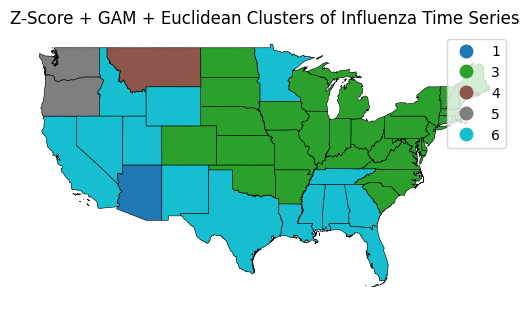

In [76]:
# USA mapping
cluster_df_euclid = cluster_labels_euclid.reset_index()
cluster_df_euclid.columns = ["fips_state", "cluster"]

gdf_euclid = gdf.merge(cluster_df_euclid, on="fips_state", how="left")

fips_to_drop = [
    2, 15,     # AK, HI
    60, 66, 69, 72, 78 # AS, GU, MP, PR, VI
]

gdf_euclid = gdf_euclid[~gdf_euclid['fips_state'].isin(fips_to_drop)]

gdf_euclid = gdf_euclid.reset_index(drop=True)

plt.figure(figsize=(12, 8))
gdf_euclid.plot(column="cluster_y",
                categorical=True,
                legend=True,
                edgecolor="black",
                cmap="tab10",
                linewidth=0.4
)

plt.axis("off")
plt.title("Z-Score + GAM + Euclidean Clusters of Influenza Time Series")
plt.show()

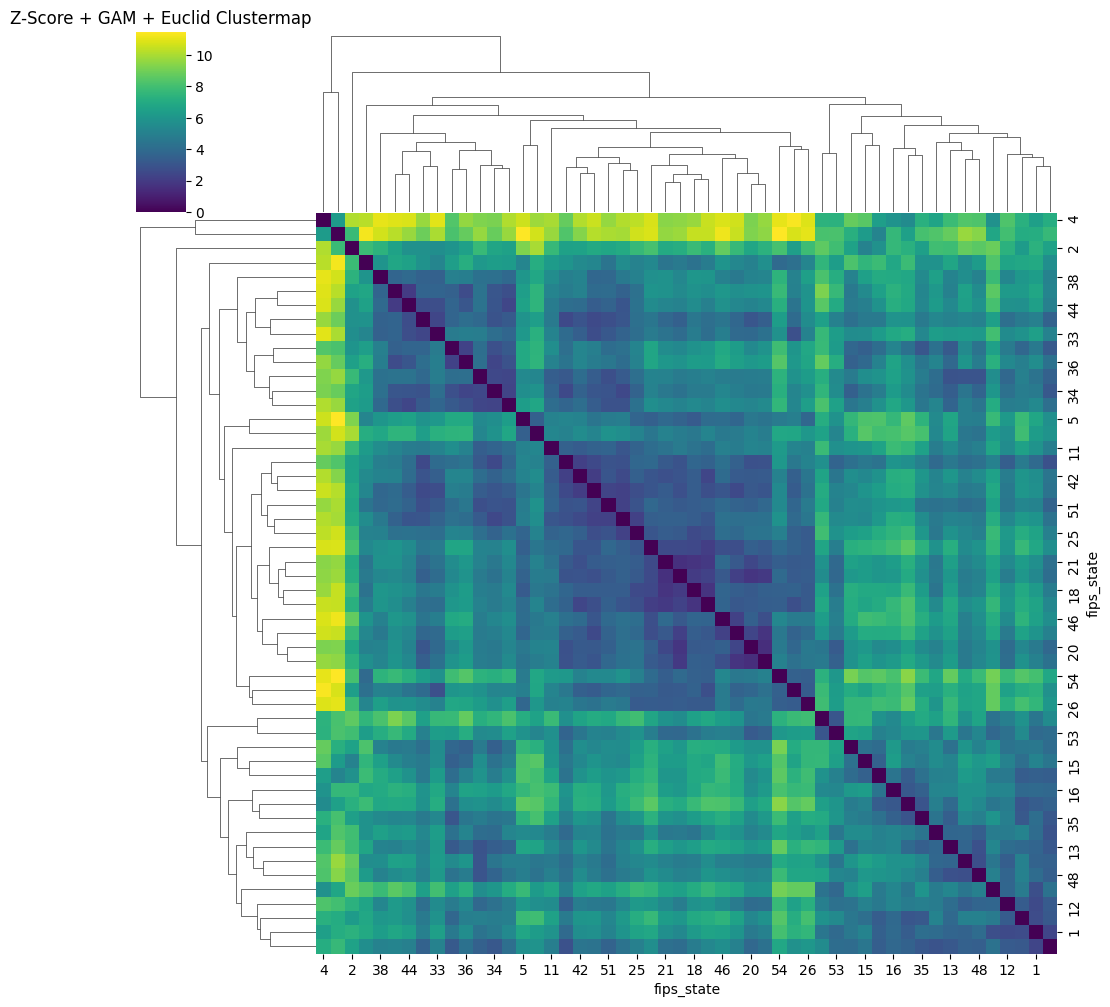

In [77]:
plot_dtw_clustermap(euclid_df, "Z-Score + GAM + Euclid Clustermap")

In [78]:
#%pip install spopt

In [79]:
# try MaxP on Z-Score + GAM
import libpysal
from spopt.region import MaxPHeuristic
import numpy as np

ts_final = ts_zscore_gam.T 


In [80]:
# threshold - num of states in cluster
# covariates - add MDS of euclid, DTW, both? potentially mobility data?

In [81]:
from sklearn.manifold import MDS

mds = MDS(n_components=5, dissimilarity="precomputed", random_state=21, normalized_stress = True) #normalized_stress ?

mds_coords = mds.fit_transform(euclid_df.values)

print(mds.stress_) # 0.04155 from 5 mds cols

mds_df = pd.DataFrame(mds_coords, index=euclid_df.index, columns=["mds_1", "mds_2", "mds_3", "mds_4", "mds_5"])

0.044330675500213905


/opt/anaconda3/envs/Influenza-DTW-Clustering/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/opt/anaconda3/envs/Influenza-DTW-Clustering/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/opt/anaconda3/envs/Influenza-DTW-Clustering/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


In [82]:
mds_df

,mds_1,mds_2,mds_3,mds_4,mds_5
fips_state,,,,,
1,0.770772,3.108946,-0.028731,0.370714,-1.446431
2,3.013266,-2.848900,-2.134040,-3.181121,-2.368562
4,-0.360395,6.313889,-4.670395,-1.780553,-1.457797
5,-2.904581,0.063973,1.550454,0.107106,3.205664
6,1.407490,4.653393,-0.671996,1.139676,-0.197917
8,-0.725299,-0.755211,-1.469516,0.346194,-2.763587
9,-1.103647,-3.432800,-0.046334,1.190098,-1.971005
10,1.295340,-1.460268,0.964472,0.054335,-0.782479
11,-0.426034,-1.203476,-1.258246,2.599108,1.951090


In [83]:
gdf_maxp = gdf.merge(ts_final, left_on="fips_state", right_index=True) # what was being done before (below)
gdf_maxp = gdf_maxp.merge(mds_df, left_on="fips_state", right_index=True) # (now merge MDS)

In [84]:
include = [
    'mds_1', 'mds_2', 'mds_3', 'mds_4', 'mds_5'
]

attr_names = [c for c in gdf_maxp.columns if c in include] # tell maxp to just cluster based on the information from the 5 MDS cols


In [85]:
gdf_maxp.head(2)

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry,...,2026-03-28 00:00:00,2026-04-04 00:00:00,2026-04-11 00:00:00,2026-04-18 00:00:00,2026-04-25 00:00:00,mds_1,mds_2,mds_3,mds_4,mds_5
0,31,01779792,0400000US31,31,NE,Nebraska,00,198956658395,1371829134,"POLYGON ((-104.05351 41.15726, -104.05267 41.2...",...,-0.468367,-0.598664,-0.665239,-0.671424,-0.638900,1.364670,0.177313,1.905096,-0.525482,1.750701
1,53,01779804,0400000US53,53,WA,Washington,00,172112588220,12559278850,"MULTIPOLYGON (((-122.32834 48.02134, -122.3217...",...,-0.463516,-0.510879,-0.538006,-0.556583,-0.566581,1.395396,2.607703,-0.117058,-0.830430,1.988363


/var/folders/zq/jdtp_f8131n5pbvkz1qqpsym0000gp/T/ipykernel_64592/1046871083.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf_maxp)


<Figure size 1200x800 with 0 Axes>

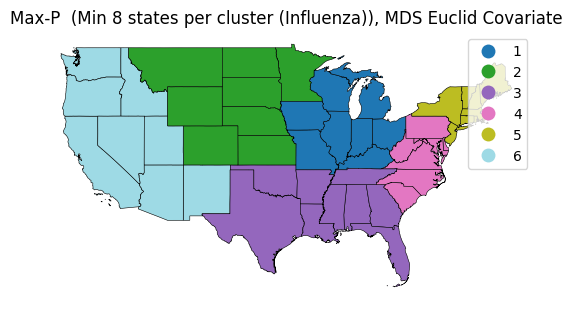

In [86]:
w = libpysal.weights.Queen.from_dataframe(gdf_maxp)

gdf_maxp['count_var'] = 1
threshold = 8

# top_down=True?
model = MaxPHeuristic(gdf_maxp,
                      w,
                      attr_names,
                      "count_var",
                      threshold,
                      max_iterations_construction=500,
                      max_iterations_sa=10
                      )
model.solve() # add params ^

gdf_maxp["cluster_maxp"] = model.labels_

plt.figure(figsize=(12, 8))
gdf_maxp.plot(column="cluster_maxp", categorical=True, legend=True, cmap="tab20", edgecolor="black",linewidth=0.4)
plt.title(f"Max-P  (Min {threshold} states per cluster (Influenza)), MDS Euclid Covariate")
plt.axis("off")
plt.show()

In [87]:
# create consensus clusters

In [88]:
def build_co_association_matrix(fips_list, labels):
    fips = list(fips_list)
    n = len(fips)
    mat = pd.DataFrame(0.0, index=fips, columns=fips)
    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                mat.iloc[i,j] = 1.0
    return mat

In [89]:
# no parallel processing for now
n_runs = 500
thres = 8 # creates 6 clusters, takes a fraction of a sec per run. thres = 9 makes 5 clusters but takes 20 sec per run.

all_labels = []
all_matrices = []

for i in range(n_runs):
    w = libpysal.weights.Queen.from_dataframe(gdf_maxp, use_index=False)

    model = MaxPHeuristic(
        gdf_maxp,
        w,
        attrs_name=attr_names,
        threshold_name="count_var",
        threshold=thres,
        max_iterations_construction=500, # these are the params we decided were best for the dengue project. could totally be diff here, can run many times in bash to determine here what's best
        max_iterations_sa=10, # try varying
    )
    model.solve()

    labels = model.labels_.copy()
    all_labels.append(labels)
    all_matrices.append(build_co_association_matrix(gdf_maxp["fips_state"], labels))

    if i % 50 == 0:
        print(f"run {i}/{n_runs}")


# average coassoc matrices
prob_matrix = sum(all_matrices) / n_runs

# consensus clustering
distance = np.clip(1 - prob_matrix, 0, 1)

n_clusters = int(np.median([len(np.unique(l)) for l in all_labels]))
print(f"median number of clusters across runs: {n_clusters}") # should just be 6

Z = linkage(squareform(distance, checks=False), method="average")
gdf_maxp["consensus_cluster"] = fcluster(Z, n_clusters, criterion="maxclust")

run 0/500
run 50/500
run 100/500
run 150/500
run 200/500
run 250/500
run 300/500
run 350/500
run 400/500
run 450/500
median number of clusters across runs: 6


<Figure size 1200x800 with 0 Axes>

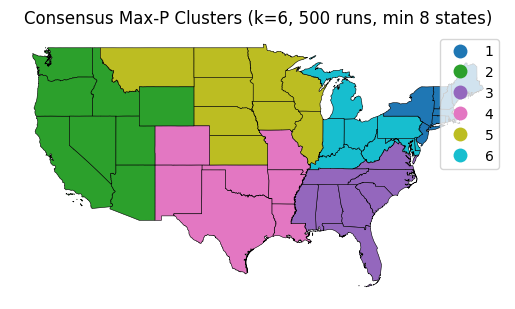

In [90]:
# plot the consensus clusters
gdf_cons = gdf_maxp[~gdf_maxp["fips_state"].isin(fips_to_drop)]

plt.figure(figsize=(12, 8))
gdf_cons.plot(column="consensus_cluster", categorical=True,
              legend=True, cmap="tab10", edgecolor="black",
              linewidth=0.4)
plt.axis("off")
plt.title(f"Consensus Max-P Clusters (k={n_clusters}, {n_runs} runs, min {thres} states)")
plt.show()

In [91]:
# skater - hierarchical but still spatially constrained
# or try adding a spatial penalty term rather than enforcing contiguity

In [92]:
# try skater

In [93]:
# tell skater to cluster based off of the z-score normalized, GAM-smoothed ts for now
exclude_skater = [
    'STATEFP', 'STATENS', 'AFFGEOID', 'GEOID', 'STUSPS', 'NAME',
    'LSAD', 'ALAND', 'AWATER', 'geometry', 'fips_state',
    'count_var', 'cluster_maxp', 'consensus_cluster',
    'mds_1', 'mds_2', 'mds_3', 'mds_4', 'mds_5','cluster'
]

attr_names_skater = [c for c in gdf_maxp.columns if c not in exclude_skater]

In [94]:
attr_names_skater

[Timestamp('2023-10-07 00:00:00'),
 Timestamp('2023-10-14 00:00:00'),
 Timestamp('2023-10-21 00:00:00'),
 Timestamp('2023-10-28 00:00:00'),
 Timestamp('2023-11-04 00:00:00'),
 Timestamp('2023-11-11 00:00:00'),
 Timestamp('2023-11-18 00:00:00'),
 Timestamp('2023-11-25 00:00:00'),
 Timestamp('2023-12-02 00:00:00'),
 Timestamp('2023-12-09 00:00:00'),
 Timestamp('2023-12-16 00:00:00'),
 Timestamp('2023-12-23 00:00:00'),
 Timestamp('2023-12-30 00:00:00'),
 Timestamp('2024-01-06 00:00:00'),
 Timestamp('2024-01-13 00:00:00'),
 Timestamp('2024-01-20 00:00:00'),
 Timestamp('2024-01-27 00:00:00'),
 Timestamp('2024-02-03 00:00:00'),
 Timestamp('2024-02-10 00:00:00'),
 Timestamp('2024-02-17 00:00:00'),
 Timestamp('2024-02-24 00:00:00'),
 Timestamp('2024-03-02 00:00:00'),
 Timestamp('2024-03-09 00:00:00'),
 Timestamp('2024-03-16 00:00:00'),
 Timestamp('2024-03-23 00:00:00'),
 Timestamp('2024-03-30 00:00:00'),
 Timestamp('2024-04-06 00:00:00'),
 Timestamp('2024-04-13 00:00:00'),
 Timestamp('2024-04-

<Figure size 1200x800 with 0 Axes>

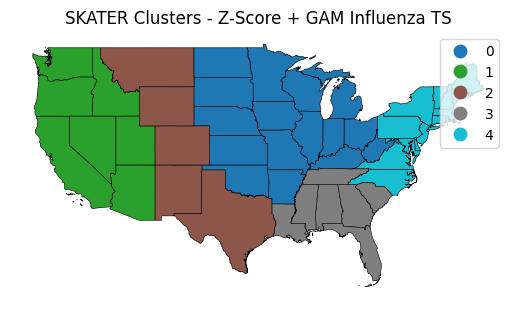

In [95]:
from spopt.region import Skater
from sklearn.metrics.pairwise import euclidean_distances

w = libpysal.weights.Queen.from_dataframe(gdf_maxp, use_index=False)

model_skater = Skater(
    gdf_maxp,
    w,
    attrs_name=attr_names_skater,
    n_clusters=5,
    floor=1, # 1
    spanning_forest_kwds={"dissimilarity": euclidean_distances} # try DTW w/ SC band set to 1 or 2
)
model_skater.solve()

gdf_maxp["cluster_skater"] = model_skater.labels_
gdf_sk = gdf_maxp[~gdf_maxp["fips_state"].isin(fips_to_drop)]

plt.figure(figsize=(12, 8))
gdf_sk.plot(column="cluster_skater", categorical=True,
            legend=True, cmap="tab10", edgecolor="black",
            linewidth=0.4)
plt.axis("off")
plt.title("SKATER Clusters - Z-Score + GAM Influenza TS")
plt.show()

# use quality metrics to figure out optimal num of clusters, min states per cluster. whether using raw TS vs. MDS covars works better.
# silhouette scores, moran's I. we want to maximize spatial correlation

# skater.con, redcap next

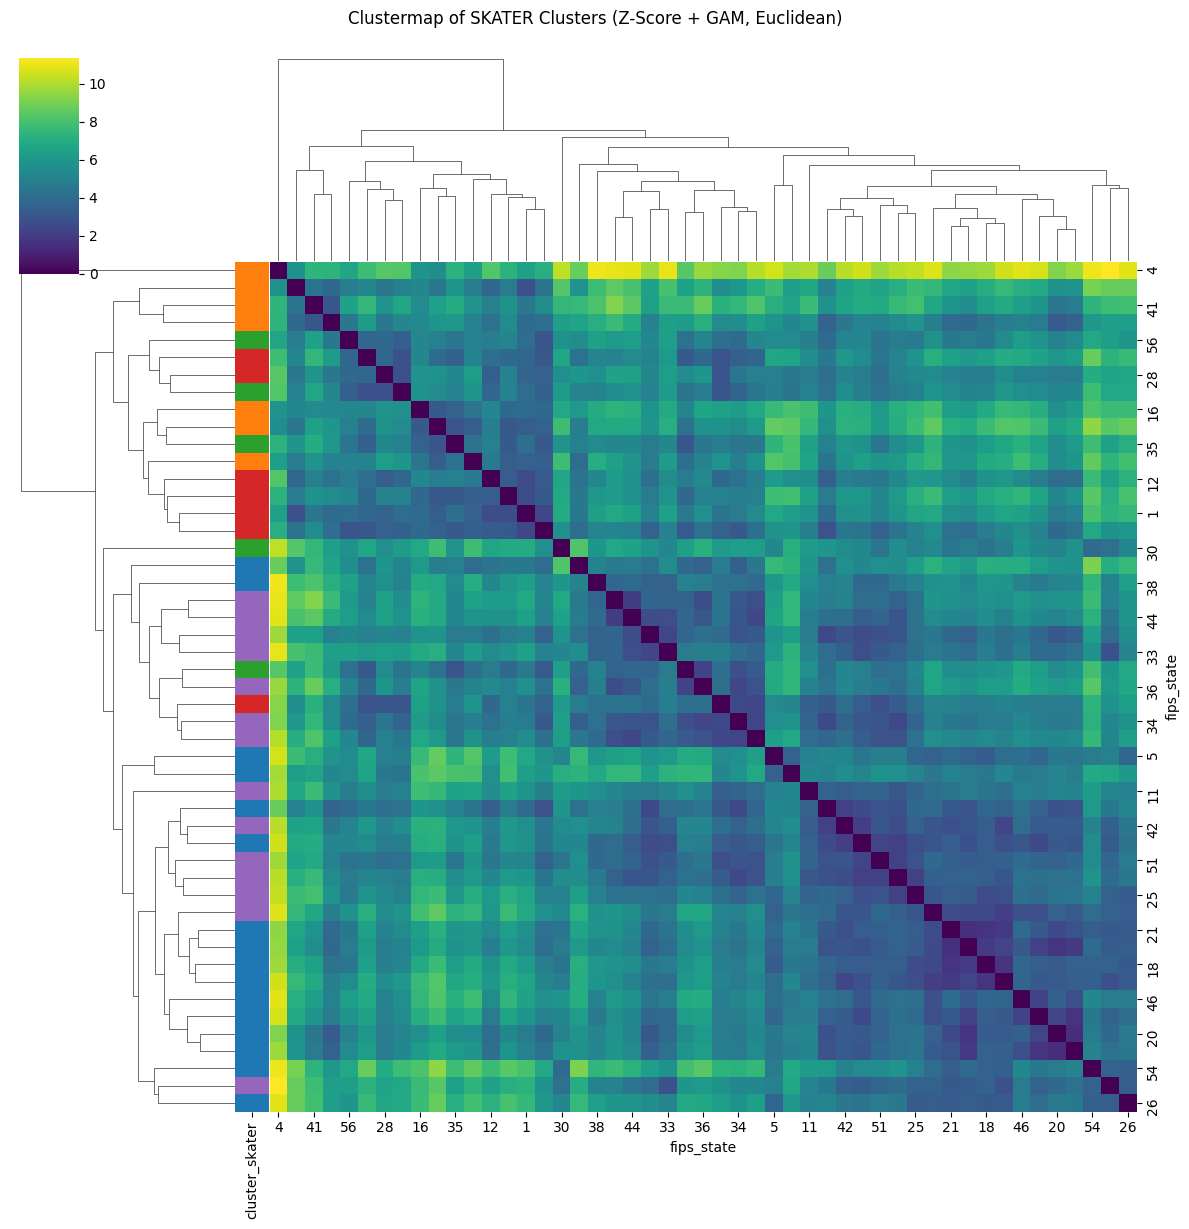

In [96]:
# clustermap

fips_to_drop_all = [c for c in [2, 15, 60, 66, 69, 72, 78] if c in euclid_df.index]
euclid_df_filtered = euclid_df.drop(index=fips_to_drop_all, columns=fips_to_drop_all)

condensed = squareform(euclid_df_filtered.values)
linkage_mat = linkage(condensed, method="average")

# get the skater clusters. visualize on the side to see if states most similar to each other (based on euclidean) are actually grouped together
cluster_colors = gdf_maxp.set_index("fips_state")["cluster_skater"]
cluster_colors = cluster_colors.loc[euclid_df_filtered.index]
palette = sns.color_palette("tab10", n_colors=cluster_colors.nunique())
lut = dict(zip(sorted(cluster_colors.unique()), palette)) # lookup table matching cluster numbers to colors
row_colors = cluster_colors.map(lut)

g = sns.clustermap(
    euclid_df_filtered,
    row_linkage=linkage_mat,
    col_linkage=linkage_mat,
    row_colors=row_colors,
    cmap="viridis",
    figsize=(12, 12)
)
g.fig.suptitle("Clustermap of SKATER Clusters (Z-Score + GAM, Euclidean)", y=1.02)
plt.show()